Description: TwoD Case

- Post-processing one case
This part of the notebook is organized such that the first few blocks, up to "Basic analysis," perform the initial analysis and save the options for subsequent blocks. Therefore, the first few blocks need to be executed each time.

Some analysis functions are implemented in separate Python files to facilitate the generation of test functions and maintain version control. These functions are then called in the code blocks of the notebook, where additional plotting and organizing utilities are used to produce figures and tables.

- Post-processing multiple cases
This part of the notebook is organized such that the first few blocks require input from user and process the information of the cases 
The following blocks perform the initial analysis and save the options for subsequent blocks.

# Package Import (Global)

In [1]:
## Import block
import os, sys
import datetime
import numpy as np
import pandas as pd
from shutil import rmtree, copy
from matplotlib import pyplot as plt
from matplotlib import gridspec, cm, rcdefaults
from matplotlib.ticker import MultipleLocator
from pathlib import Path

# default colors for plot
default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

# root path of package
root_path = os.path.join(Path().resolve().parent.parent.parent)

if str(os.path.abspath(root_path)) not in sys.path:
    sys.path.insert(0, str(os.path.abspath(root_path)))

RESULT_DIR = os.path.join(root_path, 'dtemp')

if os.path.abspath(root_path) not in sys.path:
    sys.path.append(os.path.abspath(root_path))

from hamageolib.utils.handy_shortcuts_haoyuan import Mute
from hamageolib.utils.exception_handler import my_assert
from hamageolib.utils.plot_helper import scale_matplotlib_params
    
# py_temp file
py_temp_dir = os.path.join(root_path, "py_temp_files")
os.makedirs(py_temp_dir, exist_ok=True) # Ensure the directory exists

today_date = datetime.datetime.today().strftime("%Y-%m-%d") # Get today's date in YYYY-MM-DD format
py_temp_file = os.path.join(py_temp_dir, f"py_temp_{today_date}.sh")

if not os.path.exists(py_temp_file):
    bash_header = """#!/bin/bash
# =====================================================
# Script: py_temp.sh
# Generated on: {date}
# Description: Temporary Bash script created by Python
# =====================================================

""".format(date=today_date)
    with open(py_temp_file, "w") as f:
        f.write(bash_header)

print(f"File ensured at: {py_temp_file}")

# constants
year = 365*24.0*3600.0 # s in year

File ensured at: /home/lochy/ASPECT_PROJECT/HaMaGeoLib/py_temp_files/py_temp_2026-02-26.sh


## Global path of data directory

In [2]:
## local directory
local_TwoDSubduction_dir = "/mnt/lochz/ASPECT_DATA/TwoDSubduction"
local_TwoDSubduction_alternative_dir = "/mnt/lochy/ASPECT_DATA/TwoDSubduction"

assert(os.path.isdir(local_TwoDSubduction_dir))

# Create Cases

## Set case options

Here we set case options including:
1. Baseline options to read from (base_json_path, base_dir and prm files there in).
2. User selected options.
3. Slurm options

In [3]:
create_group = False

if create_group:

    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import CreateGroup, CASE_TWOD, CASE_OPT_TWOD
    
    base_json_path = os.path.join(root_path, "hamageolib/research/haoyuan_2d_subduction/legacy_files/reference_TwoD/241016/case.json")
    base_dir = os.path.join(root_path, "hamageolib/research/haoyuan_2d_subduction/legacy_files/reference_TwoD/241016")
    slurm_file_path = os.path.join(root_path, "scripts/slurm/250816/job_hive_high.sh")
    output_dir = os.path.join(local_TwoDSubduction_dir, "EBA_CDPT_test_gr_5")

    group_json = \
    {
        "base name": "eba_cdpt", 
        "base json": base_json_path,
        "base directory": base_dir,
        "output directory": output_dir,
        "slurm base file": slurm_file_path,
        "combine case run": 1,
        "base features":[
        {
            "name": "version",
            "key": ["version"],
            "unit": "",
            "values": [3.0],
            "abbreviating strings": [""]
        },
        {
            "name": "branch to use",
            "key": ["branch"],
            "unit": "",
            "values": ["master_TwoD_rebase"],
            "abbreviating strings": [""]
        },
        {
            "name": "Refine Wedge",
            "key": ["refinement", "refine wedge"],
            "unit": "1",
            "values": [1],
            "abbreviating strings": [""]
        },
        {
            "name": "lookup table morb mixing, 1: iso stress (weakest), 2: iso strain (strongest), 3: log (intermediate)",
            "key": ["lookup table morb", "mixing model"],
            "unit": "1",
            "values": [3],
            "abbreviating strings": [""]
        },
    	],
        "features":[
            {
                "name": "use lookup table morb",
                "key": ["use lookup table morb"],
                "unit": "1",
                "values": [0, 1],
                "abbreviating strings": ["FCWL", "PTWL"]
            },
            {
                "name": "Age of the subducting plate",
                "key": ["world builder", "subducting plate", "age trench"],
                "unit": "yr",
                "values": [20e6, 40e6, 80e6, 120e6, 150e6],
                "abbreviation by value": 1,
                "abbreviating value options": ["SA", 1e-6]
            },
            {
                "name": "Age of the overiding plate",
                "key": ["world builder", "overiding plate", "age"],
                "unit": "yr",
                "values": [40e6, 80e6],
                "abbreviation by value": 1,
                "abbreviating value options": ["SA", 1e-6]
            },
            {
                "name": "Thickness of the shear zone / crust",
                "key": ["shear zone", "thickness"],
                "unit": "m",
                "values": [5e3, 7.5e3, 15e3, 20e3],
                "abbreviation by value": 1,
                "abbreviating value options": ["cd", 1e-3]
            },
            {
                "name": "Refinement level, note this is a summarized parameter of the refinement scheme assigned",
                "key": ["refinement level"],
                "unit": "1",
                "values": [10, 11, 12],
                "abbreviation by value": 0,
                "abbreviating strings": ["gr10", "gr11", "gr12"]
            }
        ],
        "bindings": [[1, 2, 0, 1, 1], [1, 2, 1, 1, 1]],
        "slurm": [
           {
             "slurm file": slurm_file_path,
             "build directory": "master_TwoD",
             "tasks per node": 64,
             "cpus": 64
           }
       ]
    }


## Creation

In [4]:
if create_group:
    CreateGroup(group_json, CASE_TWOD, CASE_OPT_TWOD)

# Data sync

## Sync with a size limit

Here I sync with a size limt on the total file. This is used to sync to hive, where there is a dual system and the work directory is quota-limited.

This is controlled by
- total_size_limit (in GB)
- start_index: starting from an index of case to catch up on a previous syncing process

In [5]:
sync_2d_data = False

if sync_2d_data:

    total_size_limit = 500.0
    start_index = 73

    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import CASE_SUMMARY_TWOD, CASE_OPTIONS
    from hamageolib.utils.file_reader import get_directory_size_du, get_relative_path
    import subprocess

    class BigCaseError(Exception):
        pass

    Case_Summary = CASE_SUMMARY_TWOD(VISIT_OPTIONS=CASE_OPTIONS)

    o_path_csv = os.path.join(local_TwoDSubduction_dir, "case_summary.csv")
    my_assert(os.path.isfile(o_path_csv), FileExistsError, "The syncing utility is based on a group summary file.")

    Case_Summary.import_file(o_path_csv)

    total_size_count = 0.0
    end_index = None
    ab_paths_to_sync = []
    for i, ab_path in enumerate(Case_Summary.ab_paths):
        if i < start_index:
            continue
        dir_size = get_directory_size_du(ab_path, "GB")
        total_size_count += dir_size
        if total_size_count > total_size_limit:
            if i == start_index:
                raise BigCaseError("Even the first case is bigger than the set size limit")
            end_index = i - 1
            break
        ab_paths_to_sync.append(ab_path)

    print("end_index = ", end_index)        
    print(ab_paths_to_sync)

    # save to a file for syncing
    file_list_path = os.path.join(local_TwoDSubduction_dir, "file_list.txt")
    file_list_1_path = os.path.join(local_TwoDSubduction_alternative_dir, "file_list.txt")
    with open(file_list_path, 'w') as fout:
        with open(file_list_1_path, 'w') as fout1:
            for i1, ab_path in enumerate(ab_paths_to_sync):
                try:
                    r_path = get_relative_path(ab_path, os.path.abspath(local_TwoDSubduction_dir))
                except FileNotFoundError:
                    r_path = get_relative_path(ab_path, os.path.abspath(local_TwoDSubduction_alternative_dir))
                    root_foo = os.path.abspath(local_TwoDSubduction_alternative_dir)
                    f = fout1
                else:
                    root_foo = os.path.abspath(local_TwoDSubduction_dir)
                    f = fout
                
                all_files = [str(p.relative_to(root_foo)) for p in Path(ab_path).rglob("*") if p.is_file()]
                
                for _file in all_files:
                    f.write(_file + '\n')

    print("Write file ", file_list_path)
    print("Write file ", file_list_1_path)

    # save 
    with open(py_temp_file, 'w') as fout:
        fout.write("#!/bin/bash\n")
        fout.write("cd %s\n" % local_TwoDSubduction_dir)
        fout.write("rsync -avu --files-from=file_list.txt ./ hive:/quobyte/billengrp/lochy/TwoDSubduction/\n")
        fout.write("cd %s\n" % local_TwoDSubduction_alternative_dir)
        fout.write("rsync -avu --files-from=file_list.txt ./ hive:/quobyte/billengrp/lochy/TwoDSubduction/\n")

    subprocess.run(["chmod", "+x", py_temp_file])
    print("Write file ", py_temp_file)


# Post-processing

- Inputs:
* local_TwoDSubduction_dir - Directory to case folder
* case name (relative path to local_TwoDSubduction_dir)

check the case_summary.csv for a full list of cases

In [6]:
## Case name

# F70sa80oa40Rwedgehr11
# case_name = "EBA_CDPT_refine_wedge2/eba_cdpt_SA80.0_ct7.5_cd70.0_gr11"
# F100sa80oa40Rwedgehr11
case_name = "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11"
# F100sa80oa40s100Rwedgehr11
# case_name = "EBA_CDPT_test_gr_3/eba_cdpt_FCWL_SA80.0_cd7.5_ss100.0_gr11"
# Psa80oa40Rwedgehr11
# case_name = "EBA_CDPT_test_gr_1/eba_cdpt_PTWL_SA80.0_cd7.5_gr11"
# Psa80oa40dual2.3sv19.5
# case_name = "EBA_CDPT26/eba_cdpt_coh500_SA80.0_OA40.0_du2.3_sv19.5_gr12"
# Psa80oa40dual0.75sv19
# case_name = "EBA_CDPT26/eba_cdpt_coh500_SA80.0_OA40.0_du0.8_sv19_gr12_particles_lb"


local_dir = os.path.join(local_TwoDSubduction_dir, case_name)

# local_dir = "/mnt/lochy/ASPECT_DATA/MOW/mow_tests/test_foo2"

assert(os.path.isdir(local_dir))

Initially, we call the CASE_OPTIONS class to gather and interpret options stored in the prm and wb file, to make further analysis easier

In [7]:
from hamageolib.research.haoyuan_2d_subduction.legacy_tools import VISIT_OPTIONS_TWOD as CASE_OPTIONS

CaseOptions = CASE_OPTIONS(local_dir)
CaseOptions.Interpret()

## Small Utilities

Small utilites:

* converting between timestep and time
* pinpointing the coordinates after rotation for the cartesian geometry

#### Pin the step and timestep

In [8]:
pin_step_and_time = False

if pin_step_and_time:

    time_array = [2657734.1895482726,8433749.335695306,12713715.302491104]

    for i, _time in enumerate(time_array):
        _time1, timestep, _ = CaseOptions.get_timestep_by_time(_time)
        print("%d: %.2f %f" % (i, _time, timestep))

#### pinpointing

In [9]:
# in case of the chunk geometry, query the cartesian coordinates of a spherical point
# this is useful to interact with Paraview slices

pinpointing_chunk_rotation = True

if pinpointing_chunk_rotation:
    
    from hamageolib.research.haoyuan_2d_subduction.legacy_utilities import ggr2cart

    r = CaseOptions.options['OUTER_RADIUS']

    rotation_lon = CaseOptions.options['ROTATION_ANGLE'] # + rotation_plus # automatic rotation
    # rotation_lon = 54.5689 # assign rotation
    # 
    print("rotation angle = ", rotation_lon)
    print("lon at 90 deg (top) = ", 90.0 - rotation_lon)

    ## Deal with solution.vtu
    # x, y, z = ggr2cart(0.0,trench_lon / 180.0 * np.pi,r - 5e3) # query a point near slab edge

    ## Deal with transform (a rotation is applied)
    pin_lon = 35.5 # deg
    depth = 0.0
    x, y, z = ggr2cart(0.0,(pin_lon+rotation_lon) / 180.0 * np.pi,r - depth) # query a point near slab edge;

    print("(x, y, z) = (%.3f, %.3f, %.3f)" % (x, y, z))

rotation angle =  52.027135763250776
lon at 90 deg (top) =  37.972864236749224
(x, y, z) = (274884.599, 6365067.121, 0.000)


## Basic Analysis

The next block will generate plots of runtime, solver statistics, etc. It will also compose a script to run in ParaView or VisIt.


- max_velocity: useful for rescaling the color for the velocity. To pick a reasonable value, first view the range from outputs with max_velocity set to -1.0. The unit to use is m/yr.
- plot_types: one or multiple inputs in ["upper_mantle", "whole", "whole_whole", "wedge_bigger", "wedge_02252025"]. I recommand using just one. It's more garanteed that the ploting script will work.
- graphical_steps: a list of steps to plot. This is the steps the vtu files are saved. For what we are concerned with, 0 is 0 Ma, 1 is 0.1 Ma, 2 is 0.2 Ma, etc.
- additional_fields: this is needed when multiple crustal layer are used in the model (and they are called with different names).


In order to get a zoom-in plot of the mantle wedge region:

- choose "upper_mantle" as the plot_type first (with the default rotation setting "rotation_plus = 0.47"). This will plot the upple mantle, then run the "Automazed workflow to finalize visualization" to plot the figure within a frame. This is 15 degree wide, so it will give you a sense where the trench is.
- tip - how to not mess up: always plus or minus some value to the default "rotation_plus = 0.47", this should have already taken you to the region near the trench. It's at most a few degree to adust.
- Then switch to the plot type of wedge_02252025 and adjust the plot.
- If one also want to plot the interface points from post-processing, first navigate to the section below "Plot slab surface temperature", run the script there and get the interface points. Then add "plot_slab_interface_points = "True"" below. The script generated this way will automatically load the vtp file containing the point. The points will be plotted with crust field in the plot type of wedge_02252025.
- Same for the option of plotting the points at the two decoupling depth, these are generated by the "Analyze slab morphology" block below and could be plotted with "plot_mdd_extract_profile_points = True"
- plot_P_trans_contours and plot_P_trans_contour_levels extract contours from the slab and define the level of contours to extract.

### Linear plots + Paraview scripts

In [10]:
do_linear_plot_paraview_scripts = False

if do_linear_plot_paraview_scripts:

    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import PlotCaseRun, PlotCaseRunTwoD
    from hamageolib.research.haoyuan_2d_subduction.workflow_scripts import run_2d_subduction_visualization

    # resample steps by a time interval
    time_interval = 5e5 # 2. use a time interval, for making animations
    resampled_df = CaseOptions.resample_visualization_df(time_interval)

    # define a function for round values
    round_values = lambda values: [round(x) for x in values]

    # prepare the graphical_steps
    graphical_steps = [80]; slices=None # 1. specify steps

    # types of plot to include
    # The available types of plots are ["upper_mantle", "whole", "whole_whole", "wedge_bigger", "wedge_02252025"]
    plot_types = ["wedge_02252025"]; rotation_plus = 0.47+2 # for plotting the upper mantle


    # Additional fields in case of two crustal layers
    # additional_fields = ["spcrust_up", "spcrust_low"]  # in case of two crustal layers
    additional_fields = [] # in case of one crustal layer

    # todo_thin
    config = {
        "RESULT_DIR": RESULT_DIR,                   # directory to write output .txt
        "py_temp_file": py_temp_file,          # where to write pvpython script
        "PlotCaseRun_base": PlotCaseRun,                               # your PlotCase module
        "PlotCaseRun_project": PlotCaseRunTwoD,                       # your TwoDPlotCase module

        # ---
        # Visualization and plotting options
        # True: save a complete result
        # False: prepare for figures in a paper
        # ---
        "plot_axis": False,
        "graphical_steps": graphical_steps,
        "slices": None,
        "max_velocity": -1.0,
        "plot_types": plot_types,
        "rotation_plus": rotation_plus,
        "additional_fields": [],
        "CaseOptions": CaseOptions,
        "plot_crust_contour_level": 0.5, # level of crust contour
        "plot_slab_interface_points": "True", # plot slab interface points
        "plot_mdd_extract_profile_points": "True",  # plot horizontal profile
        "plot_mdd_extract_profile_depths": [40e3, 70e3, 100e3],  # # plot horizontal profile at these depths
        "plot_T_shallow_contours": "True", # plot the temperature contours in shalow mantle region
        "plot_P_trans_contours": "False", # plot the pressure contours in the region of transiton
        "plot_P_trans_contour_levels": np.arange(1.5e9, 3.1e9, 0.1e9).tolist(),
        "plot_non_adiabatic_pressure_range": [-200e6, 200e6]
    }

    # previous configurations
    # P contours in the range of transition (small wedge)
    # "plot_P_trans_contour_levels": np.arange(1.5e9, 3.1e9, 0.1e9).tolist(),
    # P contours in the range of transition (bigger wedge; wedge_02252025)
        # "plot_P_trans_contour_levels": np.arange(1e9, 4.6e9, 0.5e9).tolist(),

    run_2d_subduction_visualization(local_dir, config)

### Automazed workflow to finalize visualization

In this part, the figure generated from Paraview is finalized with prepared frames

In [11]:
finalize_visual = False

if finalize_visual:
    
    from hamageolib.research.haoyuan_2d_subduction.workflow_scripts import finalize_visualization_2d_12172024, finalize_visualization_2d_wedge_12202024,\
    finalize_visualization_2d_wedge_02252025, finalize_visualization_2d_wedge_small_03282025

    from IPython.display import Image, display

    _time = 8e6
    
    # file types
    # file_name = "viscosity"
    # file_name = "T"
    # file_name = "spcrust_wedge"
    # file_name = "T_wedge"
    # file_name = "density"
    # file_name = "metastable"

    # file_name = "T_wedge_02252025"
    # file_name = "spcrust_wedge_02252025"
    # file_name = "strain_rate_wedge_02252025"
    file_name = "viscosity_wedge_02252025"
    # file_name = "nonadiabatic_pressure_wedge_02252025"

    # file_name = "T_wedge_bigger"
    
    # file_name = "T_wedge_small"
    # file_name = "spcrust_wedge_small"
    # file_name = "viscosity_wedge_small"
    # file_name = "strain_rate_wedge_small"
    # file_name = "nonadiabatic_pressure_wedge_small"
    
    if file_name in ["viscosity", "T", "density", "metastable"]:
        # frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/upper_mantle_frame_03132024_trans_with_frame-01.png"
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/upper_mantle_frame_12172024_trans-01.png"
        
        output_image_file = finalize_visualization_2d_12172024(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)

    elif file_name in ["T_wedge", "spcrust_wedge", "viscosity_wedge", "strain_rate_wedge", "DM_wedge"]:
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/upper_mantle_frame_01162025_trans.png"
        
        output_image_file = finalize_visualization_2d_wedge_12202024(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)
    
    elif file_name in ["T_wedge_02252025", "spcrust_wedge_02252025", "viscosity_wedge_02252025", "strain_rate_wedge_02252025", "DM_wedge_02252025", "nonadiabatic_pressure_wedge_02252025"]:
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_frame_022522025_trans-01.png"
        
        output_image_file = finalize_visualization_2d_wedge_02252025(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)

    elif file_name in ["T_wedge_small", "viscosity_wedge_small", "strain_rate_wedge_small", "spcrust_wedge_small", "nonadiabatic_pressure_wedge_small"]:
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_small_frame_03272025_trans.png"
        output_image_file = finalize_visualization_2d_wedge_small_03282025(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)


    elif file_name in ["T_wedge_bigger"]:
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_frame_11272024_trans.png"
        # frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_frame_11272024_trans_with_trench_frame.png"

        output_image_file = finalize_visualization_2d_wedge_02122025(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)

    else:
        raise ValueError("File name error (%s)" % file_name)

    # Displays the final combined image in the notebook.
    display(Image(filename=output_image_file))

    print("Saved plot: ", output_image_file)

### Plot the horizontal average profile

In the following code block, we read the depth average output, parse it to discrete steps and plot the selected step

In [12]:
plot_da = False

if plot_da:

    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import PlotDaFigure

    plot_time = 0

    depth_average_path = os.path.join(local_dir, 'output', 'depth_average.txt')
    assert(os.path.isfile(depth_average_path))

    fig_path_base = os.path.join(local_dir, 'img', 'DepthAverage.pdf')
    PlotDaFigure(depth_average_path, fig_path_base, time=plot_time)

### Plot the viscosity profile

In the following code block, we first read in the case options, and create synthetic viscosity profiles from these options.

In [13]:
# Calculate the viscosity profile

plot_viscosity_profile = False

if plot_viscosity_profile:
    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import CASE_TWOD, CASE_OPT_TWOD, create_case_with_json
    from hamageolib.research.haoyuan_2d_subduction.workflow_scripts import plot_pressure_temperature, plot_viscosity_components


    # Load a JSON file and create a case instance with options.
    json_opt = os.path.join(local_dir, "case.json")  # Path to the JSON configuration file.
    assert(os.path.isfile(json_opt))  # Ensure the JSON file exists.

    Case_local_reload = create_case_with_json(json_opt, CASE_TWOD, CASE_OPT_TWOD, is_reload=True)  # Load case with options.

    print(Case_local_reload.viscosity_profile)  # Output the viscosity profile.

    # Extract relevant fields from the viscosity profile for plotting.
    depth = Case_local_reload.viscosity_profile['depth']  # Depth values (in meters).
    T = Case_local_reload.viscosity_profile['T']  # Temperature values (in Kelvin).
    P = Case_local_reload.viscosity_profile['P']  # Pressure values (in Pascals).
    diffusion = Case_local_reload.viscosity_profile['diffusion']  # Diffusion viscosity values.
    dislocation = Case_local_reload.viscosity_profile['dislocation']  # Dislocation viscosity values.
    composite = Case_local_reload.viscosity_profile['composite']  # Composite viscosity values.

    # Plot options for visualizing data.
    depth_limit = (0, 3000)  # Depth axis range (in kilometers).
    depth_tick_interval = 500  # Tick interval for depth axis.

    P_limit = (0, 150)  # Pressure axis range (in GPa).
    P_tick_interval = 50.0  # Tick interval for pressure axis.

    T_limit = (0, 3000)  # Temperature axis range (in Kelvin).
    T_tick_interval = 1000.0  # Tick interval for temperature axis.

    viscosity_limit = (1e18, 1e24)  # Viscosity axis range (in Pa·s, logarithmic scale).
    viscosity_tick_interval = 1.0  # Tick interval for viscosity axis (log scale).

    # Scaling parameters for plots.
    scaling_factor = 2.0  # General scaling factor for the plot size.
    font_scaling_multiplier = 2.25  # Extra scaling for fonts.
    legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
    line_width_scaling_multiplier = 2.0  # Extra scaling for line widths.

    # Scale matplotlib parameters based on specified factors.
    scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # Create subplots for data visualization.
    fig, axes = plt.subplots(ncols=2, figsize=(12 * scaling_factor, 6 * scaling_factor))

    # Plot 1: Depth vs Pressure with a twin axis for Temperature.
    ax1 = axes[0]
    ax1_twin = ax1.twiny()

    plot_pressure_temperature(ax1, ax1_twin, depth, P, T)

    # Plot 2: Depth vs Viscosity components (log scale).
    ax2 = axes[1]
    plot_viscosity_components(ax2, depth, diffusion, dislocation, composite)

    # Adjust layout and display the plots.
    plt.tight_layout()
    plt.show()

    # save figure
    img_dir = os.path.join(local_dir, "img")
    if not os.path.isdir(img_dir):
        os.mkdir(img_dir)
    o_path = os.path.join(img_dir, "viscoisity_profile.png")
    fig.savefig(o_path)
    print("Saved figure: ", o_path)

    # Reset matplotlib parameters to defaults.
    plt.rcdefaults()

## Advance analysis

In this part, we include more advanced analysis. These typically read into the vtu file generated by the model.

- slab morphology
- slab temperature

### Analyze slab morphology.


#### Generate morphology outputs

time_interval - Interval to analyze. Results will be resampled given this time interval. 0.5e6 is tested to give the best results in terms of capturing the trending and smearing out minor spikes.

* Note
In the original notebook, this is run with a command line with parallel utilities.

In [14]:
analyze_slab_morphology = True

#### settings

Extra options:
- extract_depths: generate lateral profile at different depth. This could be plotted by the "Analyze velocity around the mdds" option 

In [15]:
if analyze_slab_morphology:
    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import SlabMorphologyCaseTwoD, SlabMorphology_dual_mdd
    
    findmdd_tolerance = 0.1
    project_velocity = True

#### Generate for one step

Configurations

* mdd1_dx0 - position of the bottom surface for figuring out mdd1. The default option is INITIAL_SHEAR_ZONE_THICKNESS*4/3
* mdd1_dx1 - position of the top surface for figuring out mdd1. The default option is -INITIAL_SHEAR_ZONE_THICKNESS
* mdd2_dx0 - position of the bottom surface for figuring out mdd2. The default option is INITIAL_SHEAR_ZONE_THICKNESS*4/3
* mdd2_dx1 - position of the top surface for figuring out mdd2. The default options is INITIAL_SHEAR_ZONE_THICKNESS*4/3

In [16]:
analyze_slab_morphology_generate_new_file_step = False
if analyze_slab_morphology and analyze_slab_morphology_generate_new_file_step:

    _time = 8e6

    _, _, vtu_step =  CaseOptions.get_timestep_by_time(_time)

    SlabMorphology_dual_mdd(local_dir, int(CaseOptions.options['INITIAL_ADAPTIVE_REFINEMENT'])+vtu_step,
                            rewrite=1,
                            n_crust=CaseOptions.options["N_CRUST"],
                            findmdd=True,
                            mdd1_dx0 = CaseOptions.options["INITIAL_SHEAR_ZONE_THICKNESS"]*4.0/3.0,
                            mdd1_dx1 = -CaseOptions.options["INITIAL_SHEAR_ZONE_THICKNESS"]*1.0,  # position of the top surface for figuring out mdd1
                            mdd2_dx0 = CaseOptions.options["INITIAL_SHEAR_ZONE_THICKNESS"]*4.0/3.0, # position of the bottom surface (below) for figuring out mdd2
                            mdd2_dx1 = CaseOptions.options["INITIAL_SHEAR_ZONE_THICKNESS"]*4.0/3.0, # position of the top surface (above) for figuring out mdd2
                            time_interval=time_interval,
                            project_velocity=project_velocity,
                            findmdd_tolerance=findmdd_tolerance, 
                            extract_depths=[40e3, 70e3, 100e3] # generate lateral profile at different depth
                            )


#### Generate for all steps

In [17]:

analyze_slab_morphology_generate_new_file_case = False
analyze_slab_morphology_remove_old = False

if analyze_slab_morphology and analyze_slab_morphology_generate_new_file_case:
    

    if analyze_slab_morphology_remove_old:
        # remove old results
        old_slab_morph_path = os.path.join(local_dir, "vtk_outputs", "slab_morph.txt")
        if os.path.isfile(old_slab_morph_path):
            os.remove(old_slab_morph_path)

    time_interval = 0.5e6
    
    SlabMorphologyCaseTwoD(local_dir, rewrite=1, findmdd=True, time_interval=time_interval, project_velocity=project_velocity, findmdd_tolerance=findmdd_tolerance)

#### Plot slab morphology

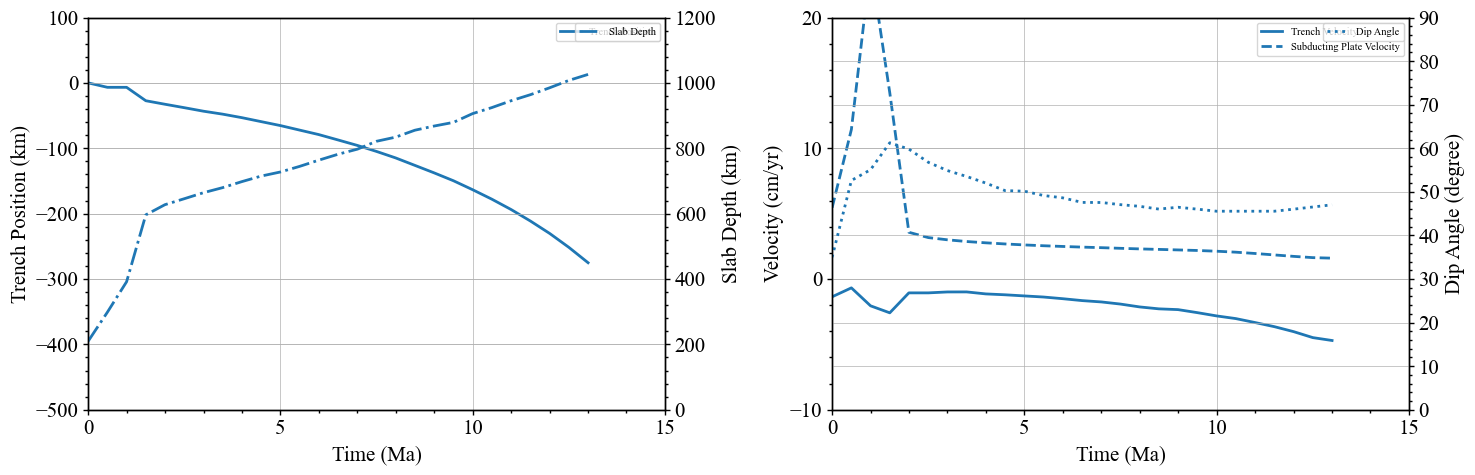

Save output file /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/img/combined_morphology.pdf


In [18]:
if analyze_slab_morphology:
    
    from hamageolib.research.haoyuan_2d_subduction.workflow_scripts import SlabAnalysisPlotter

    scaling_factor = 1.0  # scale factor of plot
    font_scaling_multiplier = 1.5 # extra scaling multiplier for font
    legend_font_scaling_multiplier = 0.5
    line_width_scaling_multiplier = 2.0 # extra scaling multiplier for lines

    # Scale matplotlib parameters based on specified factors.
    scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })
    

    # Initialize the plotter
    plotter = SlabAnalysisPlotter()

    plotter.plot_options.update({
            "time_range": (0, 15e6),
            "time_major_tick_interval": 5e6,
            "trench_range": (-500, 100),
            "trench_major_tick_interval": 100,
            "depth_range": (0, 1200),
            "depth_major_tick_interval": 200,
            "velocity_range": (-10, 20),
            "velocity_major_tick_interval": 10,
            "dip_range": (0, 90)
        })

    # Initialize the plot for "trenches" vs "times"
    fig, axes = plt.subplots(1, 2, figsize=(15*scaling_factor, 5*scaling_factor))
    
    plotter.plot_slab_analysis(axes, local_dir, CaseOptions, color=default_colors[0],\
                                include_additional_label=True)

    # Adjust spine thickness for this plot
    all_axes = fig.get_axes()
    for ax in all_axes:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)
        ax.grid()
        ax.legend()


    # Adjust layout and show the plot
    fig.tight_layout()
    plt.show()

    ofile = os.path.join(local_dir, "img", "combined_morphology.pdf")
    fig.savefig(ofile)
    print("Save output file %s" % (ofile))

    plt.show()

    rcdefaults()

### Analyze velocity around the mdds

In the following cold block, we choose a specific time step and extract the velocity profile (lateral from the slab surface) around the modelled mdd depths.

In [19]:
analyze_velocity_mdds = False

if analyze_velocity_mdds:

    _time = 8.0e6
    Ro = 6371e3

    # Example usage
    # Rule of thumbs:
    # 1. Set the limit to something like 5.0, 10.0 or 50.0, 100.0 
    # 2. Set five major ticks for each axis
    scaling_factor = 1.0  # scale factor of plot
    font_scaling_multiplier = 2.0 # extra scaling multiplier for font
    legend_font_scaling_multiplier = 0.5
    line_width_scaling_multiplier = 2.0 # extra scaling multiplier for lines
    x_lim = (-10.0, 10.0)
    x_tick_interval = 5.0   # tick interval along x
    y_lim = (0.0, 5.0)
    y_tick_interval = 1.0  # tick interval along y
    y_lim1 = (0.0, 125.0)
    y_tick_interval1 = 25.0  # tick interval along y
    n_minor_ticks = 4  # number of minor ticks between two major ones

    # scale the matplotlib params
    scale_matplotlib_params(scaling_factor, font_scaling_multiplier=font_scaling_multiplier,\
                            legend_font_scaling_multiplier=legend_font_scaling_multiplier,
                            line_width_scaling_multiplier=line_width_scaling_multiplier)

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    _, _, vtu_step =  CaseOptions.get_timestep_by_time(_time)

    # Plot using polar coordinates
    fig, ax = plt.subplots(figsize=(8*scaling_factor, 5*scaling_factor))
    ax1 = ax.twinx()

    file_names = ["mdd_extract_profile_%.5d_depth_40.00km.txt" % vtu_step, 
                  "mdd_extract_profile_%.5d_depth_70.00km.txt" % vtu_step, 
                  "mdd1_profile_%.5d.txt" % vtu_step, "mdd2_profile_%.5d.txt" % vtu_step]

    for i, file_name in enumerate(file_names):

        filein = os.path.join(local_dir, "vtk_outputs", file_name) 
        
        with open(filein, 'r') as fin:
            data = np.loadtxt(filein)

        # read values
        xs = data[:, 0]
        ys = data[:, 1]
        vx = data[:, 2]
        vy = data[:, 3]

        # derived values
        r = np.sqrt(xs**2 + ys**2)
        depth = Ro - (xs**2.0 + ys**2.0)**0.5
        fai = np.arctan2(ys, xs)

        vr = vx * np.cos(fai) + vy * np.sin(fai)
        vfai = -vx * np.sin(fai) + vy * np.cos(fai)
        v_mag = np.sqrt(vx**2 + vy**2)
        v_angle = np.pi + np.arctan2(vr, vfai)

        # center point
        n_c = int((data.shape[0]-1)/2)
        fai_c = fai[n_c]

        dist = r*(fai - fai_c)

        ax.plot(dist/1e3, 100.0*v_mag, "-", label="Magnitude (%s)" % file_name)
        ax1.plot(dist/1e3, v_angle*180.0/np.pi, "--", label="Angle")

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax1.set_ylim(y_lim1)

    ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
    
    ax1.yaxis.set_major_locator(MultipleLocator(y_tick_interval1))
    ax1.yaxis.set_minor_locator(MultipleLocator(y_tick_interval1/(n_minor_ticks+1)))

    ax.grid()

    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Velocity, Mag (cm/yr)")
    ax1.set_ylabel("Velocity, Angle (degree)")

    ax.legend()


    # Adjust spine thickness for this plot
    for spine in ax.spines.values():
        spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)

    # Reset rcParams to defaults

    fig_path = os.path.join(local_dir, "img", "mdd_velocities_%05d.pdf" % vtu_step)
    fig.savefig(fig_path)
    print("Saved figure: %s" % fig_path)

    plt.show()
    
    rcdefaults()

### Plot slab surface temperature

In this section, we will first generate temperature outputs from model results, and then plot it.

- plot_times: array of time to generate results and plot

Inside the function of SlabTemperature
- slab_envelop_interval: sample interval (along depth) in the original file. Normally set to 5e3
- slab_shallow_cutoff: sample cutoff depth in the original file. Normally set to 25e3 or 50e3. Check this with the plot generated in Paraview
- rs_n :resample interval for profile. Normally set to 5
- use_upper_crust_only: use only the top (weak-layer) composition
- offsets: We use offsets to assign profiles with a distance from the slab surface. Positive values are within the slab, negative values are in the wedge.
For How to set up these parameters, see the commented code block for configurations for different purposes.

#### Generate results at the assigned array of time

In [20]:
from hamageolib.research.haoyuan_2d_subduction.legacy_tools import SlabTemperature

plot_slab_temperature = False

# This is the option to analyze the temperature profile before plotting.
plot_slab_temperature_generate = True

if plot_slab_temperature:
    # Options
    #  plot_mdds_with_st_combined - 
    #  plot_crust_thickness - plot the crustal thickness alongside temperature profile 
    #  offsets - making profiles with offsets
    plot_mdds_with_st_combined = True
    plot_crust_thickness = True
    
    #  plot_time - time to plot (yr)
    # One method is to prescribe values in a list
    # Second method is to use a time interval, and resample the model results
    plot_times = [1e6] # 1. assign an array
    # time_interval = 1e5 # 2. use resampling
    # resampled_df = CaseOptions.resample_visualization_df(time_interval)
    # plot_times = resampled_df["Time"].to_numpy()

    offsets = [-5e3, -10e3, 7.5e3, 1e3, -1e3]

if plot_slab_temperature and plot_slab_temperature_generate:

    for plot_time in plot_times:
        # Generate results
        _, _, vtu_step =  CaseOptions.get_timestep_by_time(plot_time)
    
        vtu_snapshot = vtu_step + int(CaseOptions.options['INITIAL_ADAPTIVE_REFINEMENT']) # 0 Ma
    
        # Check if the folder exists and contains test files
        if not os.path.exists(local_dir) or not os.listdir(local_dir):
            raise FileExistsError("Skipping test: big test contents not found in 'big_tests/'.")
    
        # Make output directory and clear old files
        o_dir = os.path.join(local_dir, "vtk_outputs", "temperature")
        if not os.path.isdir(o_dir):
            os.mkdir(o_dir)
    
        o_file = os.path.join(o_dir, "slab_temperature_%05d.txt" % vtu_step)
        ofile_surface = os.path.join(o_dir, "slab_surf_points_%05d.vtp" % vtu_step)
        ofile_moho = os.path.join(o_dir, "slab_moho_points_%05d.vtp" % vtu_step)
    
        # todo_thin
        _, _, _ = SlabTemperature(local_dir, vtu_snapshot, o_file, output_slab=True,\
            fix_shallow=False,\
            # offsets from the slab surface (negative value - mantle wedge; positive value - inside the slab.)
            offsets=offsets,\
            # threshold used to derive slab contour
            slab_threshold=0.2,\
            # sample interval (along depth) in the original file
            slab_envelop_interval=1e3,\
            # sample cutoff depth in the original file
            slab_shallow_cutoff=25e3,\
            # resample interval for profile
            rs_n=5,\
            # A specific option for 2-crust case; use only the top (weak-layer) composition
            use_upper_crust_only=True,\
            n_crust=CaseOptions.options["N_CRUST"], interp_kind="linear",
            compute_crust_thickness=True, ofile_surface=ofile_surface, ofile_moho=ofile_moho)
    
            # default setup for plot weak layer with thin layer thickness 
            # fix_shallow=False,\
            # slab_shallow_cutoff=5e3,\
            # interp_kind="linear"
    
            # default setup for plot weak layer with 7.5 km, stablized condition
            # fix_shallow=True,\
            # slab_threshold=0.2,\
            # slab_shallow_cutoff=50e3
            # interp_kind="cubic"
            
            # default setup for plot weak layer with 7.5 km, earlier step
            # slab_threshold=0.7,\
            # slab_shallow_cutoff=25e3
            # interp_kind="linear"
        assert(os.path.isfile(o_file))  # assert the outputs of temperature profiles

#### Plot the temperature and viscosity of slab surface and slab moho

Note by default, we don't let the notebook to show results. But one can uncomment the "plt.show()" to make the results show in the notebook.

In [21]:
plot_slab_temperature_timesteps = True

if plot_slab_temperature and plot_slab_temperature_timesteps:


    import matplotlib as mpl
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    from scipy.interpolate import interp1d
    from matplotlib.ticker import MultipleLocator
    from hamageolib.core.AnalyticalSolution import WK2004, plate_thickness_from_age
    from hamageolib.utils.file_reader import read_aspect_header_file
    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import HeatFlowRetriveProfile
    from hamageolib.core.melt import ROCK_MELTING

    # set time and depth to plot
    max_depth = 150e3

    # Retrieve the default color cycle
    default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

    # Scaling parameters for plots.
    scaling_factor = 1.6  # General scaling factor for the plot size.
    font_scaling_multiplier = 3.0  # Extra scaling for fonts.
    legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
    line_width_scaling_multiplier = 2.0  # Extra scaling for line widths
    x_tick_interval = 400.0   # tick interval along x
    y_tick_interval = 50.0   # tick interval along x
    n_minor_ticks = 4  # number of minor ticks between two major ones


    # Scale matplotlib parameters based on specified factors.
    scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # because we hard-in the offset values, let's do a few assert
    # 2nd offset (index = 1) - this is the mantle distance above the surface, needs to be -10 km
    # last offset (index = -1) - this is adjacent profile above the surface, needs to be -1 km
    # one before the lase (index = -2) - this is the adjacent profile below the surface
    assert(np.isclose(offsets[1], -10e3, rtol=1e6))
    assert(np.isclose(offsets[-1], -1e3, rtol=1e6))
    assert(np.isclose(offsets[-2], 2e3, rtol=1e6))

    for plot_time in plot_times:
    
        # initiate a class for the analytical solution
    
        model_a = plate_thickness_from_age(80.0*1e6*year)
        model_zw = plate_thickness_from_age(40.0*1e6*year)
        constants = WK2004.Constants(
            age=80.0e6*year,            # s
            U=0.05/year,                # m/s
            theta_d=np.pi/4.0, # radians
            a=model_a,               # meters from age(in s)
            zw=model_zw,
            Ta=1573.15,             # Kelvin
            Tsf=273.15,
            kappa=1e-6,
            rho=3300.0,
            cp=1250.0, # J Kg^-1 K^-1
            plate_T_model=0
        )
        
        WK_model = WK2004(constants)
        
            
        # Plot: Combine slab surface and moho into single figures
        # fig, ax = plt.subplots(figsize=(8*scaling_factor, 7*scaling_factor), tight_layout=True)
    
        fig = plt.figure(figsize=(8*2*scaling_factor, 7*2*scaling_factor), tight_layout=True)
        gs = gridspec.GridSpec(2, 2)
        ax = fig.add_subplot(gs[0, 0])
        
    
        # plot temperature at time inspected
                
        _, _, vtu_step =  CaseOptions.get_timestep_by_time(plot_time)
    
        slab_T_file_path = os.path.join(local_dir, "vtk_outputs", "temperature", "slab_temperature_%05d.txt" % (vtu_step))
        if os.access(slab_T_file_path, os.R_OK):
            print(f"File is accessible: {slab_T_file_path}")
        else:
            raise FileNotFoundError(f"The file at '{slab_T_file_path}' is not accessible or does not exist.")
    
        # Read simulation log data
        pd_data = read_aspect_header_file(slab_T_file_path)
    
        # Define the interpolate function for temperatures
        Tbot_func = interp1d(pd_data["depth"], pd_data["Tbot"], assume_sorted=True) 
        Ttop_func = interp1d(pd_data["depth"], pd_data["Ttop"], assume_sorted=True) 
        logEtatop_func = interp1d(pd_data["depth"], pd_data["LogEtatop"], assume_sorted=True) 
        id_n2 = len(offsets)-2
        logEtaoffset_func_2n = interp1d(pd_data["depth"], pd_data["LogEtaoffset %d" % (id_n2)], assume_sorted=True) 
        Toffset_0_func = interp1d(pd_data["depth"], pd_data["Toffset 0"], assume_sorted=True) 
        Toffset_1_func = interp1d(pd_data["depth"], pd_data["Toffset 1"], assume_sorted=True) 
        Toffset_2_func = interp1d(pd_data["depth"], pd_data["Toffset 2"], assume_sorted=True) 
        Toffset_3_func = interp1d(pd_data["depth"], pd_data["Toffset 3"], assume_sorted=True) 
    
        # Get the plotting depth, temperatures
        p_depths = np.arange(pd_data["depth"][0], max_depth, 1e3)
        p_Tbots = Tbot_func(p_depths)
        p_Ttops = Ttop_func(p_depths)
        p_logEtatops = logEtatop_func(p_depths)
        p_logEtaoffset_2n = logEtaoffset_func_2n(p_depths)
        p_Toffset_0 = Toffset_0_func(p_depths)
        p_Toffset_1 = Toffset_1_func(p_depths)
        p_Toffset_2 = Toffset_2_func(p_depths)
        p_Toffset_3 = Toffset_3_func(p_depths)
    
        if plot_crust_thickness:
            Hcr_func = interp1d(pd_data["depth"], pd_data["crustal thickness"], assume_sorted=True)
            p_Hcrs = Hcr_func(p_depths) 
    
        # Mask for depth 
        mask_zw = (p_depths > model_zw)
    
        model_T1 = np.full(p_depths.shape, WK_model.Tsf)
        model_Ts = np.full(p_depths.shape, WK_model.Tsf)
        model_alphas = np.full(p_depths.shape, 0.0)
    
        with Mute():
            model_T1[mask_zw] = WK_model.mw_temperature(p_depths[mask_zw])
            model_Ts[mask_zw] = WK_model.ss_temperature(p_depths[mask_zw], use_top_thickness=True)
            model_alphas[mask_zw] = WK_model.top_thickness(p_depths[mask_zw])
            
        
        # plot options 
        # only label the surface in case there are too many labels in the figure
        color0=default_colors[5]
        color1=default_colors[6]
        ax.plot(p_Ttops - 273.15, p_depths/1e3, label="Surface T (%s Ma)" % (plot_time/1e6), linewidth=2, color=color0)
        ax.plot(p_Tbots - 273.15, p_depths/1e3, linewidth=4, color=color0, label="Moho T")
        # ax.plot(model_T1 - 273.15, p_depths/1e3, linewidth=1, linestyle="--", color=color0, label="Analytic Wedge")
    
        ax.plot(p_Toffset_0 - 273.15, p_depths/1e3, linewidth=2, linestyle="--", color=color0, label="offset %.1f km" % (-offsets[0]/1e3)) 
        ax.plot(p_Toffset_1 - 273.15, p_depths/1e3, linewidth=2, linestyle="-.", color=color0, label="offset %.1f km" % (-offsets[1]/1e3)) 
        ax.plot(p_Toffset_2 - 273.15, p_depths/1e3, linewidth=2, linestyle="-.", color=color0, label="offset %.1f km" % (-offsets[2]/1e3)) 
        ax.plot(p_Toffset_3 - 273.15, p_depths/1e3, linewidth=2, linestyle="-.", color=color0, label="offset %.1f km" % (-offsets[3]/1e3)) 
    
        if plot_mdds_with_st_combined:
            _, time_step, _ = CaseOptions.get_timestep_by_time(plot_time)
            hfs_masked, Phis_masked, mdds, trench_40km, shallow_trench = HeatFlowRetriveProfile(local_dir, plot_time, time_step, CaseOptions)
            if shallow_trench is None:
                raise ValueError("shallow trench value is not accessible for case %s" % local_dir)
    
            # phi0, phi1 = Phis_masked[0], Phis_masked[-1]
            mdd1_depth, mdd2_depth = mdds[0], mdds[1]
    
            ax.hlines(mdd1_depth/1e3, 0.0, 1200.0, linestyle="dashdot", color=color0) # mdd1
            ax.hlines(mdd2_depth/1e3, 0.0, 1200.0, linestyle="dotted", color=color0) # mdd2
    
        # model prediction of temperature in the top thermal bd
        WL_thickness = 3e3
        model_alpha = 10e3 + WL_thickness
        # model_alpha = "mdd"
        model_x = WL_thickness # distance to the "surface"
        # model_x = "crust_thickness"
        if isinstance(model_x, float):
            appendix = "x_%.2e" % model_x
            x_data = model_x
        elif isinstance(model_x, str):
            appendix = "x_%s" % model_x
            if model_x == "crust_thickness":
                assert(plot_crust_thickness)
                x_data = p_Hcrs
            else:
                raise NotImplementedError()
    
        if isinstance(model_alpha, float):
            alpha_data = model_alpha
            appendix += "_alpha_%.2e" % model_alpha
        if isinstance(model_alpha, str):
            if model_alpha == "mdd":
                assert(plot_mdds_with_st_combined)
                alpha1 = 10e3
                alpha2 = 10e3 + 7.5e3
                alpha_data = np.full(p_depths.shape, alpha1)
                mask_mdd1 = (p_depths > mdd1_depth) & (p_depths < mdd2_depth)
                alpha_data[mask_mdd1] = alpha1 * (p_depths[mask_mdd1] - mdd2_depth) / (mdd1_depth - mdd2_depth) +\
                      alpha2 * (p_depths[mask_mdd1] - mdd1_depth) / (mdd2_depth - mdd1_depth)
                mask1 = (p_depths > mdd2_depth)
                alpha_data[mask1] = alpha2
                appendix += "_alpha_mdd_%.2e_%.2e" % (alpha1, alpha2)
            else:
                raise NotImplementedError()
        # compute boundary temperature and plot
        model_bd_Ts = WK_model.bd_temperature_formula(p_Toffset_1, p_Tbots, alpha_data, x_data)
        ax.plot(model_bd_Ts - 273.15, p_depths/1e3, linewidth=1, linestyle="-", color=color0, label="Analytic Surface")
    
        # plot melting curves
        # Define pressure ranges for each curve in Pascals (Pa)
        rock_melting = ROCK_MELTING() # Initialize the ROCK_MELTING instance
    
        pressure_ranges = {
        "dry_peridotite": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
        "water_saturated_peridotite_low_pressure": np.linspace(0, 6e9, 100),  # 0 to 6 GPa
        "water_saturated_peridotite_high_pressure": np.linspace(6e9, 12e9, 100),  # 6 to 12 GPa
        "eclogite": np.linspace(3e9, 7.5e9, 100),  # 3 to 7.5 GPa
        "peridotite_aH2O_0.1": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
        "peridotite_aH2O_0.3": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
        "peridotite_aH2O_0.5": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
        "peridotite_aH2O_0.7": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
        "basalt_aH2O_0_3": np.linspace(0.078e9, 3.665e9, 100),  # 0.078 to 3.665 GPa
        "basalt_aH2O_0_8": np.linspace(0.078e9, 3.665e9, 100),  # 0.078 to 3.665 GPa
        "basalt_aH2O_1_3": np.linspace(0.078e9, 3.665e9, 100),  # 0.078 to 3.665 GPa
        "basalt_aH2O_1_8": np.linspace(0.078e9, 3.665e9, 100)  # 0.078 to 3.665 GPa}
        }
    
        styles = {
        "dry_peridotite": ("k", "-"),
        "water_saturated_peridotite_low_pressure": (default_colors[3], "--"),
        "water_saturated_peridotite_high_pressure": (default_colors[3], "--"),
        "eclogite": ("r", "-"),
        "peridotite_aH2O_0.1": ("c", "-"),
        "peridotite_aH2O_0.3": ("c", "--"),
        "peridotite_aH2O_0.5": ("g", "-"),
        "peridotite_aH2O_0.7": (default_colors[4], "--"),
        "basalt_aH2O_0_3": (default_colors[1], "--"),
        "basalt_aH2O_0_8": ("m", "--"),
        "basalt_aH2O_1_3": ("y", "--"),
        "basalt_aH2O_1_8": ("y", "--"),
        } # Colors and line styles for each curve
    
        solidus_list = ["basalt_aH2O_0_3", "basalt_aH2O_1_8",\
                        "water_saturated_peridotite_low_pressure", "water_saturated_peridotite_high_pressure", "peridotite_aH2O_0.7"]
    
        for name in solidus_list:
            # Plot each solidus curve
            # Hide the label names here in case there are too many in the figure
            func = rock_melting.solidus_data[name]
            P_Pa = pressure_ranges[name]  # Pressures in Pa
            T_K = func(P_Pa)  # Temperatures in K
            depth_km = P_Pa / 33e6
            color, linestyle = styles[name]
            ax.plot(T_K - 273.15, depth_km, color=color, linestyle=linestyle) # , label=name.replace("_", " ").title())
        
        ax.set_xlim([0.0, 1400.0])
        ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
        ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
        ax.set_ylim([max_depth/1e3, 0])
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
        ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
    
        ax.set_xlabel("T (C)")
        ax.set_ylabel("z (km)")
    
        ax.legend() # hide legend, see AI finalized figures.
        ax.grid()
    
        if plot_crust_thickness: 
            ax = fig.add_subplot(gs[0, 1])
            ax.plot(p_Hcrs/1e3, p_depths/1e3, label="Crustal Thickness (%s, %s Ma)" % (case_name, plot_time/1e6), linewidth=2, color=color0)
    
            ax.set_xlim([0, 30.0]) 
            ax.xaxis.set_major_locator(MultipleLocator(10.0))
            ax.xaxis.set_minor_locator(MultipleLocator(10.0/(n_minor_ticks+1)))
        
            ax.set_ylim([max_depth/1e3, 0])
            ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
            ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
        
            ax.set_xlabel("Crustal Thickness (km)")
            ax.set_ylabel("z (km)")
    
            ax.grid()

        # plot surface viscosity
        ax = fig.add_subplot(gs[1, 0])
        ax.plot(p_logEtatops, p_depths/1e3, label="Surface viscosity (%s Ma)" % (plot_time/1e6), linewidth=2, color=color0)
        ax.plot(p_logEtaoffset_2n, p_depths/1e3, label="%.1f km viscosity (%s Ma)" % (-offsets[id_n2]/1e3, plot_time/1e6), linewidth=2, color=color1)
        
        ax.set_xlim([19.0, 24.0])
        ax.xaxis.set_major_locator(MultipleLocator(1.0))
        ax.xaxis.set_minor_locator(MultipleLocator(1.0/(n_minor_ticks+1)))

        ax.set_ylim([max_depth/1e3, 0])
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
        ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))

        ax.set_xlabel("log(Viscosity) (Pa *s)")
        ax.set_ylabel("z (km)")
    
        ax.legend() # hide legend, see AI finalized figures.
        ax.grid()
    
        
    
        # Adjust spine thickness for this plot
        all_axes = fig.get_axes()
        for ax in all_axes:
            for spine in ax.spines.values():
                spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)
        
        # Save figure
        # o_path = os.path.join(local_dir, "img", "temperature", "slab_temperature_combined2_t%.4e.pdf" % (plot_combine_cases_st_time))
        o_path = os.path.join(local_dir, "img", "temperature", "slab_temperature_compare_%s_t%.4e.pdf" % (appendix, plot_time))
        if not os.path.isdir(os.path.dirname(o_path)):
            os.mkdir(os.path.dirname(o_path))
    
        fig.savefig(o_path)
        print("Saved figure: %s" % o_path)
        
        # show figure
        plt.show()

    mpl.rcParams.update(mpl.rcParamsDefault)

#### Plot the temperol results

1. Plot the slab surface and moho temperature at 100 km
2. Take the curve 1 km from the slab surface (Given by the last in the offsets array)

* depth_lookup - Look up the temperature at a certain depth.
* T_inspect - Inspect where the surface temperature first reach this value

In [22]:

plot_slab_temperature_temporal_results = False

if plot_slab_temperature and plot_slab_temperature_temporal_results:


    import matplotlib as mpl
    from scipy.interpolate import interp1d
    from hamageolib.utils.file_reader import read_aspect_header_file
    
    
    # assert that we include a profile 1 km from the slab surface
    id_n1 = len(offsets)-1
    assert(np.isclose(offsets[id_n1], -1.0e3, rtol=1e-6))
    
    # set a maximum depth for diagnose data    
    max_depth = 100e3
    depth_lookup= 80e3
    depth_surf_moho_lookup = 100e3
    T_inspect = 750 + 273.15  # 800 C
    
    # array to record the max depth and temperature at a profile 1 km above the slab surface
    T_lookup_1km_array = np.zeros(plot_times.size)
    T_top_lookup_array = np.zeros(plot_times.size)
    T_bot_lookup_array = np.zeros(plot_times.size)
    depth_max_1km_array = np.zeros(plot_times.size)
    
    for i, plot_time in enumerate(plot_times):
    
            # Access temperature file at time inspected
            _, _, vtu_step =  CaseOptions.get_timestep_by_time(plot_time)
        
            slab_T_file_path = os.path.join(local_dir, "vtk_outputs", "temperature", "slab_temperature_%05d.txt" % (vtu_step))
            if os.access(slab_T_file_path, os.R_OK):
                print(f"File is accessible: {slab_T_file_path}")
            else:
                raise FileNotFoundError(f"The file at '{slab_T_file_path}' is not accessible or does not exist.")
        
            # Read simulation log data
            pd_data = read_aspect_header_file(slab_T_file_path)
        
            # Define the interpolate function for temperatures
            try:
                Tbot_func = interp1d(pd_data["depth"], pd_data["Tbot"], assume_sorted=True) 
                Ttop_func = interp1d(pd_data["depth"], pd_data["Ttop"], assume_sorted=True) 
                Toffset_0_func = interp1d(pd_data["depth"], pd_data["Toffset 0"], assume_sorted=True) 
                Toffset_1_func = interp1d(pd_data["depth"], pd_data["Toffset 1"], assume_sorted=True) 
                Toffset_2_func = interp1d(pd_data["depth"], pd_data["Toffset 2"], assume_sorted=True) 
                Toffset_last_func = interp1d(pd_data["depth"], pd_data["Toffset %d" % id_n1], assume_sorted=True) 
            except KeyError:
                depth_max_1km_array[i] = np.nan
                T_lookup_1km_array[i] = np.nan
                continue
    
        
            # Get the plotting depth, temperatures
            p_depths = np.arange(pd_data["depth"][0], max_depth, 1e3)
            p_Tbots = Tbot_func(p_depths)
            Tbot_lookup = Tbot_func(depth_surf_moho_lookup)
            p_Ttops = Ttop_func(p_depths)
            Ttop_lookup = Ttop_func(depth_surf_moho_lookup)
            p_Toffset_0 = Toffset_0_func(p_depths)
            p_Toffset_1 = Toffset_1_func(p_depths)
            p_Toffset_2 = Toffset_2_func(p_depths)
            p_Toffset_last = Toffset_last_func(p_depths)
            T_offset_last_inpect = Toffset_last_func(depth_lookup)
    
            # Get the peak with a profile 1 km from the slab
            mask = p_Toffset_last > T_inspect
            if np.any(mask):
                i_inspect = np.where(mask)[0][0]
                depth_inspect = p_depths[i_inspect]
            else:
                i_inspect = None  # or raise an error
                depth_inspect = None
    
            depth_max_1km_array[i] = depth_inspect
            T_lookup_1km_array[i] = T_offset_last_inpect
            T_bot_lookup_array[i] = Tbot_lookup
            T_top_lookup_array[i] = Ttop_lookup
    
    
    # Retrieve the default color cycle
    default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]
    
    # Scaling parameters for plots.
    scaling_factor = 1.6  # General scaling factor for the plot size.
    font_scaling_multiplier = 3.0  # Extra scaling for fonts.
    legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
    line_width_scaling_multiplier = 2.0  # Extra scaling for line widths
    n_minor_ticks = 4  # number of minor ticks between two major ones
    
    
    # Scale matplotlib parameters based on specified factors.
    scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )
    
    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })
    
    fig = plt.figure(figsize=(12*scaling_factor, 7*2*scaling_factor), tight_layout=True)
    gs = gridspec.GridSpec(2, 1)
    
    # Plot the slab surface and moho temperature with time
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(plot_times/1e6, T_top_lookup_array - 273.15, linewidth=2, color=default_colors[0])
    ax.plot(plot_times/1e6, T_bot_lookup_array - 273.15, linewidth=4, color=default_colors[0])
    
    ax.set_xlabel("Time (Ma)") # Set axis name
    ax.set_ylabel("Temperature (C)")
    
    x_tick_interval = 5.0 # Set ticks
    ax.set_xlim([0, 15.0])
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    
    y_tick_interval = 200.0
    ax.set_ylim([200.0, 1200.0])
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
    
    ax.grid()
    
    # Plot both the temperature lookup and the depth where temperature is hot than the temperature inspected
    ax = fig.add_subplot(gs[1, 0])
    ax_twinx = ax.twinx()
    ax.plot(plot_times/1e6, T_lookup_1km_array - 273.15, color=default_colors[0])
    ax_twinx.plot(plot_times/1e6, depth_max_1km_array/1e3, linestyle="--", color=default_colors[0])
    
    ax.set_xlabel("Time (Ma)") # Set axis name
    ax.set_ylabel("Temperature (C)")
    ax_twinx.set_ylabel("Depth (km)")
    
    x_tick_interval = 5.0 # Set ticks
    ax.set_xlim([0, 15.0])
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    
    y_tick_interval = 100.0
    ax.set_ylim([600.0, 1100.0])
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
    
    y1_tick_interval = 20.0
    ax_twinx.set_ylim([0.0, 100.0])
    ax_twinx.yaxis.set_major_locator(MultipleLocator(y1_tick_interval))
    ax_twinx.yaxis.set_minor_locator(MultipleLocator(y1_tick_interval/(n_minor_ticks+1)))
    
    ax.grid()
    
    plt.show()
    
    file_path = os.path.join(local_dir, "img", "temperature", "slab_temperature_inspect_t%.4e.pdf" % (plot_time))
    fig.savefig(file_path)
    print("Saved file figure %s" % file_path)
        
    # reset mpl default settings    
    mpl.rcParams.update(mpl.rcParamsDefault)

## Plot The heat flux

The following block processes and visualizes heat flux data in a specific region along a trench, based on boundary and slab morphology data

Boundary Data Handling

The script retrieves geometric parameters (inner and outer radii) from Visit_Options and initializes an object to read boundary output data. It processes the data to compute the heat flux between the inner and outer radii and converts the boundary coordinates from Cartesian to spherical form.

The first code block below processes the heat flux output from a single step, given a specified model time, and generates the corresponding plot. 

The second code block iterates through the steps of a single case and organizes the results of the heat flow profiles.

In [23]:
# This block processes the heat flux output from a single step, given a specified model time, and generates the corresponding plot.
# Set the time of interest in years (8 million years), 
# retrieve the timestep corresponding to the specified time, 
# construct the input file path based on the timestep, 
# and print details about the file, time, and timestep.

plot_heat_flow_timestep = False

# times and timesteps
# times = resampled_df["Time"].values # 1. use all time steps
# time_steps = resampled_df["Time step number"].values # use values
# times = [3e6] # 2. use a specific time and figure out the time step
# idx = np.argmin(np.abs(resampled_df["Time"].values - times[0]))
# time_steps = [resampled_df["Time step number"].values[idx]]  # yr, assign values



if plot_heat_flow_timestep:

    # plot setting
    plot_time = 8.0e6
    use_shallow_trench = True

    Ro = 6371e3

    hf_dir = os.path.join(local_dir, "img", "heat_flux")
    if not os.path.isdir(hf_dir):
        os.mkdir(hf_dir)

    import matplotlib as mpl
    from matplotlib.ticker import MultipleLocator
    from scipy.interpolate import UnivariateSpline
    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import SlabEnvelopRetrivePoints, HeatFlowRetriveProfile

    # get the time step and vtu step with the given plot time
    _, time_step, vtu_step =  CaseOptions.get_timestep_by_time(plot_time)

    # Retrieve the default color cycle
    default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

    # factors for scaling
    scaling_factor = 1.75  # scale factor of plot
    font_scaling_multiplier = 3.0 # extra scaling multiplier for font
    legend_font_scaling_multiplier = 0.75
    line_width_scaling_multiplier = 2.0 # extra scaling multiplier for lines
    x_lim = (3.0, -1.0) # degree
    x_tick_interval = 1.0  # tick interval along x
    y_lim = (0.0, 100.0)
    y_tick_interval = 20.0  # tick interval along y
    n_minor_ticks = 4  # number of minor ticks between two major ones

    # Scale matplotlib parameters based on specified factors.
    scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })


    fig, ax = plt.subplots(figsize=(8*scaling_factor, 5*scaling_factor))
    
    ax1 = ax.twinx()

    # Retrieves the heat flow profile based on the given parameters.
    hfs_masked, Phis_masked, mdds, trench_40km, shallow_trench = HeatFlowRetriveProfile(local_dir, plot_time, time_step, CaseOptions)
    if shallow_trench is None:
        raise ValueError("shallow trench value is not accessible for case %s" % local_dir)

    phi0, phi1 = Phis_masked[0], Phis_masked[-1]
    mdd1_depth, mdd2_depth = mdds[0], mdds[1]
    mdd_Ls = SlabEnvelopRetrivePoints(local_dir, plot_time, CaseOptions, np.array(mdds))

    # Fit a smoothing spline to the data (s=0 gives an exact fit, increase 's' to smooth more)
    # Then calculate the first and second derivative of heat flow with respect to longitude
    hfs_spline = UnivariateSpline(Phis_masked, hfs_masked, s=0)
    dhf_dphi = hfs_spline.derivative(n=1) # unit: mw / rad

    # migrate the value of phi to center on the trench
    if use_shallow_trench:
        trench = shallow_trench
    else:
        trench = trench_40km
    ax.plot((Phis_masked - trench) * 180.0 / np.pi, hfs_masked * 1000.0, color=default_colors[0])
    ax1.plot((Phis_masked - trench) * 180.0 / np.pi, dhf_dphi(Phis_masked)/Ro*1e6, linestyle='-.', color=default_colors[0]) # unit: 1e6 * mw / m^3
    print("mdd1_depth: %.2f, mdd_Ls[0] - trench: %.2f" % (mdd1_depth, (mdd_Ls[0] - trench) * 180.0 / np.pi)) # debug
    ax.axvline((mdd_Ls[0] - trench) * 180.0 / np.pi, linestyle="--", color=default_colors[0])
    ax.axvline((mdd_Ls[1] - trench) * 180.0 / np.pi, linestyle="--")

    ax.set_xlabel("Location to trench (degree)")
    ax.set_ylabel("Heat flux (mw / m^2)")
    ax1.set_ylabel("Gradient (per km)")

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax1.set_ylim((-2.0, 2.0))

    ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
    
    # ax.set_xlabel("Trench Distance (Km)")
    # ax.set_ylabel("Heat Flux (mW/m^2)")
    # ax1.set_ylabel("Heat Flux Derivative (mw/m^3)")

    ax.grid()

    ax.legend()
    fig.tight_layout()
    
    # Adjust spine thickness for this plot
    for spine in ax.spines.values():
        spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)

    # output file name    
    ofile_basename = "heat_flux_top"
        
    if use_shallow_trench:
        ofile_basename += "_shallow_trench"
    else:
        pass

    ofile_basename += "_t%.4e" % plot_time

    ofile = os.path.join(hf_dir, ofile_basename + ".pdf")
    ofile_png = os.path.join(hf_dir, ofile_basename + ".png")
    
    fig.savefig(ofile)
    fig.savefig(ofile_png)

    print("Save output file %s" % (ofile))
    print("Save output file %s" % (ofile_png))
    
    mpl.rcParams.update(mpl.rcParamsDefault)

## Animation

### Initiation

Here we:
  - assign options for animation
  - figure out the steps to make animation based on the time_interval

Options:
  - time_interval: animation steps are based on this time interval
  - ani_plot_type: type of figure to generate, options are "upper_mantle", "whole", "wedge_bigger", "wedge_02252025"

In [24]:
is_2d_animation = True
is_2d_animation_debug_first_step = True
is_2d_animation_skip_missing_files = True

if is_2d_animation:
    from hamageolib.research.haoyuan_2d_subduction.legacy_tools import VISIT_OPTIONS_TWOD as CASE_OPTIONS
    
    assert(local_dir is not None)
    # ani_factor = 5 # every th vtu steps
    time_interval = 0.5e6

    # type of the plot to generate 
    ani_plot_type = "wedge_02252025" # "upper_mantle", "whole", "wedge_bigger", "wedge_02252025"

    # utility function
    round_values = lambda values: [round(x) for x in values]
    
    # case options 
    Case_Options = CASE_OPTIONS(local_dir)
    Case_Options.Interpret()
    Case_Options.SummaryCaseVtuStep(os.path.join(local_dir, "summary.csv"))
    # all_graphical_steps = Case_Options.summary_df["Vtu step"]
    # ani_graphical_steps = all_graphical_steps[::ani_factor]
    resampled_df = Case_Options.resample_visualization_df(time_interval)
    ani_graphical_steps = round_values(resampled_df["Time"].values / float(resampled_df.attrs["Time between graphical output"]))

    # make the animation directory
    ani_dir = os.path.join(local_dir, "img", "animation")
    if not os.path.isdir(ani_dir):
        os.mkdir(ani_dir)

### Generate Animation Figures

Here we:
- Generate script for Paraview. To do that, we turn off all the fancy options stepwise plot in the previous section.
- Record the location of the script in bash file to batch run

In [ ]:
is_2d_animation_generate_figures = True

if is_2d_animation and is_2d_animation_generate_figures:

    from hamageolib.utils.file_reader import read_aspect_header_file
    import subprocess

    # write header to script file 
    with open(py_temp_file, 'w') as fout:
        fout.write("#!/bin/bash\n")

    # options in plot
    Case_Options.options["PLOT_TYPES"] = [ani_plot_type]

    # step
    # Assert existence of the slab morphology file
    slab_morph_file = os.path.join(local_dir, 'vtk_outputs', 'slab_morph_t1.00e+05.txt')
    if not os.path.isfile(slab_morph_file):
        raise FileNotFoundError(f"The file '{slab_morph_file}' does not exist.")

    # Read simulation log data
    pd_data = read_aspect_header_file(slab_morph_file)
    pvtu_steps = pd_data["pvtu_step"]
    times = pd_data["time"]
    trenches = pd_data["trench"]
    shallow_trenches = pd_data["shallow trench"]
    slab_depthes = pd_data["slab depth"]
    sp_velocities = pd_data["subducting plate velocity"]
    ov_velocities = pd_data["overiding plate velocity"]

    # Make the directory to hold the scripts
    print("Generating paraview scripts")
    odir = os.path.join(local_dir, 'paraview_scripts', "stepwise")
    if not os.path.isdir(odir):
        os.mkdir(odir)

    # generate paraview scripts
    for i, graphical_step in enumerate(ani_graphical_steps):        
        print("i: ", i)
        print("graphical_step:", graphical_step)
        Case_Options.options['GRAPHICAL_STEPS'] = [graphical_step]

        _time = float(resampled_df.attrs["Time between graphical output"]) * graphical_step
        i1 = (np.abs(times - _time)).argmin() # index nearest to _time
        trench = shallow_trenches[i1]
        trench_deg = trench * 180.0 / np.pi

        ofile = os.path.join(odir, 'slab_%d.py' % (graphical_step))
        paraview_script = os.path.join(root_path, 'scripts', 'paraview_scripts', "TwoDSubduction", "slab.py")
        paraview_script_base = os.path.join(root_path, 'scripts', 'paraview_scripts', "base.py")
        Case_Options.read_contents(paraview_script_base, paraview_script)  # combine these two scripts

        # For mantle wedge plot, the frame needs to be rotated to center on the current trench
        # For upper mantle plot, the frame needs to be rotated to the initial trench
        if ani_plot_type in ["wedge_bigger", "wedge_02252025"]:
            Case_Options.options['ROTATION_ANGLE'] = 90.0 - trench_deg - 1.5
            Case_Options.options["PLOT_T_SHALLOW_CONTOURS"] = "True"
        else:
            Case_Options.options['ROTATION_ANGLE'] = 90.0 - Case_Options.options["THETA_REF_TRENCH"]*180.0/np.pi - 0.47
        print("ROTATION_ANGLE:", Case_Options.options['ROTATION_ANGLE'])
        Case_Options.substitute()

        Case_Options.save(ofile)

        print("Generate %s" % ofile)

        with open(py_temp_file, 'a') as fout:
            fout.write("pvpython %s\n" % ofile)

        if is_2d_animation_debug_first_step:
            break
    
    subprocess.run(["chmod", "+x", py_temp_file])

    print("Saved file %s" % py_temp_file)

Generating paraview scripts
i:  0
graphical_step: 0
ROTATION_ANGLE: 52.313131575127464
saved file: /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/paraview_scripts/stepwise/slab_0.py
Generate /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/paraview_scripts/stepwise/slab_0.py
Saved file /home/lochy/ASPECT_PROJECT/HaMaGeoLib/py_temp_files/py_temp_2026-02-26.sh


### Finalize Animation Figures

In [32]:

if is_2d_animation and is_2d_animation_generate_figures:

    from hamageolib.research.haoyuan_2d_subduction.workflow_scripts import finalize_visualization_2d_12172024, finalize_visualization_2d_wedge_12202024,\
    finalize_visualization_2d_wedge_02252025, finalize_visualization_2d_wedge_small_03282025, finalize_visualization_2d_wedge_02122025

    from IPython.display import Image, display

    # make a new directory to save animation files
    output_image_dir = os.path.join(local_dir, "img/prep")
    if os.path.isdir(output_image_dir):
        rmtree(output_image_dir)
    os.mkdir(output_image_dir)

    for i, graphical_step in enumerate(ani_graphical_steps):        
        print("i: ", i)
        print("graphical_step:", graphical_step)
        Case_Options.options['GRAPHICAL_STEPS'] = [graphical_step]

        _time = float(resampled_df.attrs["Time between graphical output"]) * graphical_step

        file_name = None

        if ani_plot_type == "upper_mantle":
            file_name = "viscosity"
            frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/upper_mantle_frame_12172024_trans-01.png"
            output_image_file = finalize_visualization_2d_12172024(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)
        elif ani_plot_type == "wedge_bigger":
            file_name = "viscosity_wedge_bigger"
            frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_frame_11272024_trans.png"
            output_image_file = finalize_visualization_2d_wedge_02122025(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)

        elif ani_plot_type ==  "wedge_02252025":
            file_name_list = ["viscosity_wedge_02252025", "T_wedge_02252025"]
            # frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_frame_022522025_trans-01.png"
            frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_frame_022522025_transz_with_frame.png"
            for file_name in file_name_list:
                output_image_file = finalize_visualization_2d_wedge_02252025(local_dir, file_name, _time, frame_png_file_with_ticks, add_time=False)

        print("Saved plot: ", output_image_file)
        
        if is_2d_animation_debug_first_step:
            break

i:  0
graphical_step: 0
Found 2 image(s) on the page.
Found matching image with dimensions: 1350x704
Saved the full figure as /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/img/real_figure.png
Overlay completed. Final image saved as /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/img/prep/viscosity_wedge_02252025_t0.0000e+00.png
Found 2 image(s) on the page.
Found matching image with dimensions: 1350x704
Saved the full figure as /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/img/real_figure.png
Overlay completed. Final image saved as /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/img/prep/T_wedge_02252025_t0.0000e+00.png
Saved plot:  /mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11/img/prep/T_wedge_02252025_t0.0000e+00.png


# Deprecated

In [ ]:
plot_case_slab_temperature_0 = False

if plot_case_slab_temperature_0:

    import matplotlib as mpl
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    from matplotlib.ticker import MultipleLocator
    
    max_depth = 250e3

    time_interval = 0.5e6
    time_end = 10.5e6
    time_inspect = 11.8e6
    x_tick_interval = 400.0   # tick interval along x
    y_tick_interval = 50.0   # tick interval along x
    n_minor_ticks = 4  # number of minor ticks between two major ones


    plot_times = np.arange(0.0, time_end, time_interval)

    # Scaling parameters for plots.
    scaling_factor = 2.0  # General scaling factor for the plot size.
    font_scaling_multiplier = 3.0  # Extra scaling for fonts.
    legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
    line_width_scaling_multiplier = 2.0  # Extra scaling for line widths


    # Scale matplotlib parameters based on specified factors.
    plot_helper.scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    ####
    # First plot: Separate slab surface and moho into separate figures
    # Follow the fashion of Van Keken 2023 review, fig 8
    ####
    # Colormap setup: Map time steps to colors
    cmap = cm.get_cmap('viridis')  # Choose colormap (viridis, plasma, coolwarm, etc.)
    norm = mcolors.Normalize(vmin=0, vmax=time_end/1e6)  # Normalize time range (0 to 1)

    fig = plt.figure(figsize=(14*scaling_factor, 6*scaling_factor), constrained_layout=True)
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.6)

    axes = [fig.add_subplot(gs[i]) for i in range(3)]

    # Tbot_range = [None, None] # Ranges of temeprature profile
    # Ttop_range = [None, None]
    for i, _time in enumerate(plot_times):
        # _time1, _, vtu_step = Visit_Options.get_timestep_by_time(_time)
        vtu_step = int(_time / 1e5) # debug
        slab_T_file_path = os.path.join(local_dir, "vtk_outputs", "temperature", "slab_temperature_%05d.txt" % (vtu_step))
        if os.access(slab_T_file_path, os.R_OK):
            print(f"File is accessible: {slab_T_file_path}")
        else:
            raise FileNotFoundError(f"The file at '{slab_T_file_path}' is not accessible or does not exist.")

        # Read simulation log data
        pd_data = read_aspect_header_file(slab_T_file_path)

        # Define the interpolate function for temperatures
        Tbot_func = interp1d(pd_data["depth"], pd_data["Tbot"], assume_sorted=True) 
        Ttop_func = interp1d(pd_data["depth"], pd_data["Ttop"], assume_sorted=True) 
        
        p_depths = np.arange(pd_data["depth"][0], np.min(np.array([pd_data["depth"][len(pd_data)-1], max_depth])), 1e3)
        p_Tbots = Tbot_func(p_depths)
        p_Ttops = Ttop_func(p_depths)

        print("p_Tbots.size: ", p_Tbots.size) # debug

        # Update the range of the temperature
        # if i == 0:
        #     Tbot_range[0] = p_Tbots
        #     Tbot_range[1] = p_Tbots
        #     Ttop_range[0] = p_Ttops
        #     Ttop_range[1] = p_Ttops
        # else:
        #     Tbot_range[0] = np.minimum(Tbot_range[0], p_Tbots)
        #     Tbot_range[1] = np.maximum(Tbot_range[1], p_Tbots)
        #     Ttop_range[0] = np.minimum(Ttop_range[0], p_Ttops)
        #     Ttop_range[1] = np.maximum(Ttop_range[1], p_Ttops)

        
        # plot options 
        color = cmap(norm(_time/1e6))  # Map time step to a color

        # plot results for one step
        axes[0].plot(p_Ttops - 273.15, p_depths/1e3, label="Surface T, %.1f Ma" % (_time/1e6), color=color)
        axes[1].plot(p_Tbots - 273.15, p_depths/1e3, label="Moho T", color=color)

    # set option for the first figure
    axes[0].set_xlim([0.0, 1200.0])
    axes[0].xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    axes[0].xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    axes[0].set_ylim([0, max_depth/1e3])
    axes[0].yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    axes[0].yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))

    axes[0].set_xlabel("T (C)")
    axes[0].set_ylabel("z (km)")

    axes[0].grid()

    # set option for the second figure
    axes[1].set_xlim([0.0, 1200.0])
    axes[1].xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    axes[1].xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    axes[1].set_ylim([0, max_depth/1e3])
    axes[1].yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    axes[1].yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))

    axes[1].set_xlabel("T (C)")
    axes[1].set_ylabel("z (km)")

    axes[1].grid()

    # Add color bar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=axes[2], ticks=np.arange(0, time_end/1e6 + 1, 5))  # Add color bar with ticks
    cbar.set_label("Time (Ma)")

    # axes[0].legend()

    # fig.tight_layout()

    # Adjust spine thickness for this plot
    all_axes = fig.get_axes()
    for ax in all_axes:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)

    # Show figure
    plt.show()

    # Save figure
    o_path = os.path.join(local_dir, "img", "temperature", "slab_temperature_combined1.pdf")
    if not os.path.isdir(os.path.dirname(o_path)):
        os.mkdir(os.path.dirname(o_path))

    fig.savefig(o_path)
    print("Saved figure: %s" % o_path)
    
    mpl.rcParams.update(mpl.rcParamsDefault)


##### Inspect a specific time step

In [ ]:
plot_case_slab_temperature_1 = True
with_legend = False

if plot_case_slab_temperature_1:

    config = {
    "Visit_Options": Visit_Options,
    "plot_helper": plot_helper,
    "times": [10.5e6], # 1. one timestep
    # "times": resampled_df["Time"].values, # 2. all timesteps with assigned interval
    "with_legend": False
    }
  
    plot_temperature_profiles_steps(local_dir, config)

    plt.show()
    # plt.close()

#### Plot The heat flux

The following block processes and visualizes heat flux data in a specific region along a trench, based on boundary and slab morphology data

##### Boundary Data Handling

The script retrieves geometric parameters (inner and outer radii) from Visit_Options and initializes an object to read boundary output data. It processes the data to compute the heat flux between the inner and outer radii and converts the boundary coordinates from Cartesian to spherical form.

The first code block below processes the heat flux output from a single step, given a specified model time, and generates the corresponding plot. 

The second code block iterates through the steps of a single case and organizes the results of the heat flow profiles.

In [ ]:
# This block processes the heat flux output from a single step, given a specified model time, and generates the corresponding plot.
# Set the time of interest in years (8 million years), 
# retrieve the timestep corresponding to the specified time, 
# construct the input file path based on the timestep, 
# and print details about the file, time, and timestep.

plot_heat_flow_timestep = False

# times and timesteps
times = resampled_df["Time"].values # 1. use all time steps
time_steps = resampled_df["Time step number"].values # use values
# times = [3e6] # 2. use a specific time and figure out the time step
# idx = np.argmin(np.abs(resampled_df["Time"].values - times[0]))
# time_steps = [resampled_df["Time step number"].values[idx]]  # yr, assign values


Ro = 6371e3

use_shallow_trench = True

if plot_heat_flow_timestep:

    hf_dir = os.path.join(local_dir, "img", "heat_flux")
    if not os.path.isdir(hf_dir):
        os.mkdir(hf_dir)

    from matplotlib import rcdefaults
    from matplotlib.ticker import MultipleLocator

    # Retrieve the default color cycle
    default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

    # factors for scaling
    scaling_factor = 1.75  # scale factor of plot
    font_scaling_multiplier = 3.0 # extra scaling multiplier for font
    legend_font_scaling_multiplier = 0.75
    line_width_scaling_multiplier = 2.0 # extra scaling multiplier for lines
    x_lim = (3.0, -1.0) # degree
    x_tick_interval = 1.0  # tick interval along x
    y_lim = (0.0, 120.0)
    y_tick_interval = 20.0  # tick interval along y
    n_minor_ticks = 4  # number of minor ticks between two major ones

    # scale the matplotlib params
    plot_helper.scale_matplotlib_params(scaling_factor, font_scaling_multiplier=font_scaling_multiplier,\
                            legend_font_scaling_multiplier=legend_font_scaling_multiplier,
                            line_width_scaling_multiplier=line_width_scaling_multiplier)

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    for i, _time in enumerate(times):

        fig, ax = plt.subplots(figsize=(8*scaling_factor, 5*scaling_factor))
        
        ax1 = ax.twinx()
    
        # Retrieves the heat flow profile based on the given parameters.
        hfs_masked, Phis_masked, mdds, trench_40km, shallow_trench = HeatFlowRetriveProfile(local_dir, _time, time_steps[i], Visit_Options)
        if shallow_trench is None:
            raise ValueError("shallow trench value is not accessible for case %s" % local_dir)

        phi0, phi1 = Phis_masked[0], Phis_masked[-1]
        mdd1_depth, mdd2_depth = mdds[0], mdds[1]
        mdd_Ls = TwoDVtkPp.SlabEnvelopRetrivePoints(local_dir, _time, Visit_Options, np.array(mdds))

        # Fit a smoothing spline to the data (s=0 gives an exact fit, increase 's' to smooth more)
        # Then calculate the first and second derivative of heat flow with respect to longitude
        hfs_spline = UnivariateSpline(Phis_masked, hfs_masked, s=0)
        dhf_dphi = hfs_spline.derivative(n=1) # unit: mw / rad

        # migrate the value of phi to center on the trench
        if use_shallow_trench:
            trench = shallow_trench
        else:
            trench = trench_40km
        ax.plot((Phis_masked - trench) * 180.0 / np.pi, hfs_masked * 1000.0, color=default_colors[0])
        ax1.plot((Phis_masked - trench) * 180.0 / np.pi, dhf_dphi(Phis_masked)/Ro*1e6, linestyle='-.', color=default_colors[0]) # unit: 1e6 * mw / m^3
        print("mdd1_depth: %.2f, mdd_Ls[0] - trench: %.2f" % (mdd1_depth, (mdd_Ls[0] - trench) * 180.0 / np.pi)) # debug
        ax.axvline((mdd_Ls[0] - trench) * 180.0 / np.pi, linestyle="--", color=default_colors[0])
        # ax.axvline((mdd_Ls[1] - trench) * 180.0 / np.pi, linestyle="--")

        ax.set_xlabel("Location to trench (degree)")
        ax.set_ylabel("Heat flux (mw / m^2)")
        ax1.set_ylabel("Gradient (per km)")

        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax1.set_ylim((-1.5, 1.5))

        ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
        ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
        ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
        
        # ax.set_xlabel("Trench Distance (Km)")
        # ax.set_ylabel("Heat Flux (mW/m^2)")
        # ax1.set_ylabel("Heat Flux Derivative (mw/m^3)")

        ax.grid()

        ax.legend()
        fig.tight_layout()
        
        # Adjust spine thickness for this plot
        for spine in ax.spines.values():
            spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)

        # output file name    
        ofile_basename = "heat_flux_top"
            
        if use_shallow_trench:
            ofile_basename += "_shallow_trench"
        else:
            pass
    
        ofile_basename += "_t%.4e" % _time

        ofile = os.path.join(hf_dir, ofile_basename + ".pdf")
        ofile_png = os.path.join(hf_dir, ofile_basename + ".png")
        
        fig.savefig(ofile)
        fig.savefig(ofile_png)

        print("Save output file %s" % (ofile))
        print("Save output file %s" % (ofile_png))

In [ ]:
# This block iterates through the steps of a single case and organizes the results of the heat flow profiles.
# HeatFlowRetriveForearcMaximumCase(local_dir, Visit_Options)

### Pick Timesteps

Pick the time steps of:

1. Slab tip reaching 660 ($t_{660}$).
2. First peak of trench motion after $t_{660}$ ($t_{p1}$), and trench velocity
3. Second peak of trench motion after $t_{660}$ ($t_{p2}$), and trench velocity

Outputs from the following block are helpful.

The t660 is extracted from the dataset.

The peak of trench motion could be picked from suggestions

In [ ]:

yr = 365 * 24 * 3600.0
radius = 6371e3

IndexByValue = lambda array_1d, val: np.argmin(abs(array_1d - val))
Resample1d = lambda array_1d, n: array_1d[np.ix_(range(0, array_1d.size, n))]

pick_timesteps_and_plot = False

if pick_timesteps_and_plot:

    # pick the right time step

    slab_morph_path = os.path.join(local_dir, "vtk_outputs", "slab_morph_t1.00e+05.txt")
    assert(os.path.isfile(slab_morph_path))

    data = np.loadtxt(slab_morph_path)
    steps = data[:, 1]
    times = data[:, 2]
    trenches = data[:, 3]
    slab_depths = data[:, 4]

    # time of slab tip reaching 660 km and the index in the list
    sfunc = interp1d(slab_depths, times, assume_sorted=True)
    t660 = sfunc(660e3)
    i660 = IndexByValue(times, t660)
    step660 = steps[i660]
    print("t660 = %.1f Ma, step660 = %d" % (t660, step660))

    t800 = sfunc(800e3)
    i800 = IndexByValue(times, t800)
    step800 = steps[i800]
    print("t800 = %.1f Ma, step800 = %d" % (t800, step800))

    t1000 = sfunc(1000e3)
    i1000 = IndexByValue(times, t1000)
    step1000 = steps[i1000]
    print("t1000 = %.1f Ma, step1000 = %d" % (t1000, step1000))

    # time of slab tip reaching 2800 km and the index in the list
    try:
        t2800 = sfunc(2800e3)
    except ValueError:
        print("t2800 = None, not reached yet")
    else:
        i2800 = IndexByValue(times, t2800)
        step2800 = steps[i2800]
        print("t2800 = %.1f Ma, step2800 = %d" % (t2800, step2800))

    # trench position
    trfunc = interp1d(trenches, times, assume_sorted=True)
    t_range = times
    tr_1st_derivatives = np.gradient(trenches, times)
    tr_2nd_derivatives = np.gradient(np.gradient(trenches, times), times)

    # trench position resampled
    # the derivatives before resampling has large variation in the value
    resampled_trenches = Resample1d(trenches, 5)
    resampled_times = Resample1d(times, 5)
    resampled_steps = Resample1d(steps, 5)
    tr_1st_resampled_derivatives = np.gradient(resampled_trenches, resampled_times)
    tr_2nd_resampled_derivatives = np.gradient(np.gradient(resampled_trenches, resampled_times), resampled_times)

    t_ranges = np.arange(0.0, times[-1] + 5e6, 5e6)
    for i in range(t_ranges.size-1):
        mask = (resampled_times > t_ranges[i]) & (resampled_times < t_ranges[i+1])
        ivmax = np.argmax(np.abs(tr_1st_resampled_derivatives[mask]))
        tvmax = resampled_times[mask][ivmax]
        vmax = tr_1st_resampled_derivatives[mask][ivmax]
        step_vmax = resampled_steps[mask][ivmax]
        print("(%.1f Ma, %.1f Ma): tvmax = %.1f Ma, step_vmax = %d, vmax = %.2e cm/yr" % (t_ranges[i]/1e6, t_ranges[i+1]/1e6, tvmax/1e6, step_vmax, vmax * radius * 100.0))

    # trench positions
    fig, ax = plt.subplots()
    ax.plot(times, trenches)
    # 1st derivatives: trench velocity, converted from rad/yr to cm/yr
    fig, ax = plt.subplots()
    ax.plot(resampled_times, tr_1st_resampled_derivatives * radius * 100, 'b')
    # 2nd derivatives: trench velocity gradient, converted from rad/yr/yr to cm/yr/yr
    ax1 = ax.twinx()
    ax1.plot(resampled_times, tr_2nd_resampled_derivatives * radius * 100, 'c--')


In [ ]:
# now, enter the picked value
Ma = 1e6
t660 = 2.7 * Ma
t_vr_max1 = 8.0 * Ma
t_vr_max2 = 12.0 * Ma

In [ ]:
plot_morph_publication = False

if plot_morph_publication:

    plt.style.use('publication_2d_morph')

    time_interval = 0.5e6
    # time_range = [0.0, times[-1]]
    time_range = [0.0, 15.0e6] # in case slab tip reaches 2890
    time_markers = [float(t660), t_vr_max1, t_vr_max2]
    # time_markers = [2.4e6, 10.3e6, 17.9e6]
    vlim = [-20.0, 20.0]
    vlim_for_ath = [-10.0, 10.0] # limit for the athenosphere velocity

    SlabPlot = TwoDVtkPp.SLABPLOT('slab')
    SlabPlot.PlotMorphPublicationBillen18(local_dir, save_pdf=True, time_interval=time_interval, time_range=time_range, time_markers=time_markers, vlim=vlim, vlim_for_ath=vlim_for_ath)

    plt.close()

    import matplotlib as mpl
    mpl.rcParams.update(mpl.rcParamsDefault)

### Combine results for one case

I take the steps from the previous block where the paraview script is generated.

In [ ]:
combine_plots_case = False

if combine_plots_case:
    # define the resize by width function to work with image.resize
    resize_by_width = lambda size, width: (int(width), int(1.0 * size[1] *  width / size[0]))

    img_dir = os.path.join(local_dir, "img")
    pv_output_dir = os.path.join(img_dir, "pv_outputs")
    assert(os.path.isdir(pv_output_dir))
    ns_image_path = os.path.join(img_dir, "newton_solver_history.png")
    assert(os.path.isfile(ns_image_path))

    # assigne this explicitly
    morph_image_path = os.path.join(local_dir, "img/morphology/trench.png")

    # new image
    # first initiate a new image
    # The work flow of the Image module includes
    # first openingthe figure and then extend that by
    # opening new figures and paste them on the first one.
    # One additional operation is appending text on the figure, this requries two additional packages
    # ImageFont and ImageDraw
    new_image_path = os.path.join(local_dir, "img", "case_combined.pdf")
    # image_size = (2700, 10000) # width, height
    image_size = (2700, int(h_last)) # width, height, do this if you want the exact height
    new_image = Image.new('RGB',image_size,(250,250,250))
    h_last = 0.0

    # 1. paste the output from the new solver
    # The figure is resized by the width of the canvas
    ns_image = Image.open(ns_image_path)
    ns_image = ns_image.resize(resize_by_width(ns_image.size, new_image.size[0]))
    new_image.paste(ns_image, (0, 0))
    h_last += ns_image.size[1]

    # 2. paste the output of the slab morphology
    if os.path.isfile(morph_image_path):
        morph_image = Image.open(morph_image_path)
        morph_image = morph_image.resize(resize_by_width(morph_image.size, new_image.size[0]))
        new_image.paste(morph_image, (0, int(h_last)))
        h_last += morph_image.size[1]

    # 2. paste the outputs from paraview
    # Note "Visit_Options" is from a previous section where these plots are generated
    steps = Visit_Options.options['GRAPHICAL_STEPS']
    h_interval = 100
    fnt0 = ImageFont.truetype("Pillow/Tests/fonts/FreeMono.ttf", int(h_interval / 3.0 * 2.0))
    for step in steps:
        _time = step * 0.1e6
        print(_time) # debug
        # a. plot of viscosity 
        vis_image_path = os.path.join(pv_output_dir, "viscosity_t%.4e.png" % _time)
        assert(os.path.isfile(vis_image_path))
        vis_image = Image.open(vis_image_path)
        # print(vis_image.size)
        vis_image = vis_image.resize(resize_by_width(vis_image.size, new_image.size[0]/2.0))
        new_image.paste(vis_image, (0, int(h_last) + h_interval))
        # b. plot of the whole mantle
        vis_whole_image_path = os.path.join(pv_output_dir, "viscosity_whole_whole_t%.4e.png" % _time)
        assert(os.path.isfile(vis_whole_image_path))
        vis_whole_image = Image.open(vis_whole_image_path)
        vis_whole_image = vis_whole_image.resize(resize_by_width(vis_whole_image.size, new_image.size[0]/2.0))
        new_image.paste(vis_whole_image, (int(np.ceil(new_image.size[0]/2.0)), int(h_last) + h_interval))
        # c. plot a sub-title, including the time
        d = ImageDraw.Draw(new_image)
        d.text((int(new_image.size[0]/2.0), h_last), "t = %.2f Ma" % (_time/1e6), font=fnt0, fill=(0, 0, 0))
        h_last += (vis_image.size[1] + h_interval)


    # save to a new figure
    new_image.save(new_image_path)



### Compare between case output

* First, load the options for all cases
* Then, try to parse the tagged case names from a case_summary file
* Next, there are a few things we can do

1. plot the heat flows and put them together.

#### Select the cases to combine

In [ ]:
# Some previous examples

## Between Perplex Case and cases with different cutoff depth
# case_summary_csv = "/mnt/lochz/ASPECT_DATA/TwoDSubduction/case_summary.csv"
# base_comp_dir = "/mnt/lochz/ASPECT_DATA/TwoDSubduction" 
# case_comp_names = ["EBA_CDPT_morb_dE/eba_cdpt_coh500_SA80.0_cd7.5_log", "EBA_CDPT18_refine_wedge1/eba_cdpt_coh500_SA80.0_cd80.0_cd7.5", "EBA_CDPT18_refine_wedge1/eba_cdpt_coh500_SA80.0_cd100.0_cd7.5", "EBA_CDPT18_refine_wedge1/eba_cdpt_coh500_SA80.0_cd200.0_cd7.5"]

## Cases with different activation energy
# case_summary_csv = "/mnt/lochz/ASPECT_DATA/TwoDSubduction/case_summary.csv"
# base_comp_dir = "/mnt/lochz/ASPECT_DATA/TwoDSubduction/EBA_CDPT_morb_dE" 
# case_comp_names = ["eba_cdpt_coh500_SA80.0_cd7.5_log", "eba_cdpt_coh500_SA80.0_cd7.5_log_dEdisl100p", "eba_cdpt_coh500_SA80.0_cd7.5_log_dEdisl100n"]
# time_list = [[2.5, 6.5, 10.8], [2.2, 6.2, 10.7], [2.5, 6.8, 10.5]]

### Cases with small shear zone thickness
# base_comp_dir = "/mnt/lochz/ASPECT_DATA/TwoDSubduction" 
# case_comp_names = ["EBA_CDPT_morb_dE/eba_cdpt_coh500_SA80.0_cd7.5_log", "EBA_CDPT26/eba_cdpt_coh500_SA80.0_OA40.0_du0.8_sv19_gr12_particles_lb"]
# time_list = [[2.5, 6.5, 10.8], [2.1, 5.6, 10.6]]

### Resolution tests
## FCWL cases: resolution
# case_comp_names = ["EBA_CDPT18_refine_wedge1/eba_cdpt_coh500_SA80.0_cd100.0_cd7.5", "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr10", "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11", "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr12"]
## PTWL cases
# case_comp_names = ["EBA_CDPT_morb_dE/eba_cdpt_coh500_SA80.0_cd7.5_log", "EBA_CDPT_test_gr_1/eba_cdpt_PTWL_SA80.0_cd7.5_gr10", "EBA_CDPT_test_gr_1/eba_cdpt_PTWL_SA80.0_cd7.5_gr11"]
## Compare FCWL and PTWL cases
# case_comp_names = ["EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11", "EBA_CDPT_test_gr_1/eba_cdpt_PTWL_SA80.0_cd7.5_gr11"]
## Cutoff depths
# case_comp_names = ["EBA_CDPT_refine_wedge2/eba_cdpt_SA80.0_ct7.5_cd70.0_gr11", "EBA_CDPT_refine_wedge2/eba_cdpt_SA80.0_ct7.5_cd80.0_gr11", "EBA_CDPT_refine_wedge2/eba_cdpt_SA80.0_ct7.5_cd90.0_gr11", "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11"]
## Shear zone viscosity
# case_comp_names = ["EBA_CDPT18_refine_wedge1/eba_cdpt_coh500_SA80.0_cd100.0_cd7.5", "EBA_CDPT24_2/eba_cdpt_coh500_SA80.0_ss500.0_sv21_cd100.0_dc7.5", "EBA_CDPT23_4_re/eba_cdpt_coh500_cd100.0_cd7.5_sv19"]

In [ ]:
from shilofue.TwoDSubduction0.Cases import CASE, CASE_OPT
from shilofue.Cases import create_case_with_json

# Whether to plot
case_summary_csv = "/mnt/lochz/ASPECT_DATA/TwoDSubduction/case_summary.csv"
base_comp_dir = "/mnt/lochz/ASPECT_DATA/TwoDSubduction" 

# case_comp_names = ["EBA_CDPT_refine_wedge2/eba_cdpt_SA80.0_ct7.5_cd70.0_gr11", "EBA_CDPT_refine_wedge2/eba_cdpt_SA80.0_ct7.5_cd80.0_gr11", "EBA_CDPT_refine_wedge2/eba_cdpt_SA80.0_ct7.5_cd90.0_gr11", "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11"]

# case_comp_names = ["EBA_CDPT_test_gr_4/eba_cdpt_FCWL_SA40.0_OA20.0_cd7.5_ss500.0_gr11", "EBA_CDPT_test_gr_4/eba_cdpt_PTWL_SA40.0_OA20.0_cd7.5_ss500.0_gr11"]

# case_comp_names = ["EBA_CDPT23_6/eba_cdpt_coh500_SA80.0_ss100.0",  "EBA_CDPT_test_gr_3/eba_cdpt_FCWL_SA80.0_cd7.5_ss100.0_gr10", "EBA_CDPT_test_gr_3/eba_cdpt_FCWL_SA80.0_cd7.5_ss100.0_gr11"]

# case_comp_names = ["EBA_CDPT18_refine_wedge1/eba_cdpt_coh500_SA80.0_cd100.0_cd7.5", "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr10", "EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11"]

case_comp_names = ["EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11", "EBA_CDPT_test_gr_1/eba_cdpt_PTWL_SA80.0_cd7.5_gr11"]

# case_comp_names = ["EBA_CDPT_test_gr_0/eba_cdpt_FCWL_SA80.0_cd7.5_gr11"]

plot_combine_cases = True

# Cases Options
time_list = [[], [], []]

visual_file_name_list = ['viscosity']

Ro = 6371e3

# Retrieve the default color cycle
default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]
colors = [
    'blue',       # Standard blue
    'cyan',       # Bright cyan
    'red',        # Standard red
    'orange',     # Bright orange
    'purple',     # Deep purple
    'brown',      # Earthy brown
    'pink',       # Soft pink
    'gray',       # Neutral gray
    'magenta'     # Bright magenta
]

# Scaling parameters for plots.
scaling_factor = 2.0  # General scaling factor for the plot size.
font_scaling_multiplier = 2.25  # Extra scaling for fonts.
legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
line_width_scaling_multiplier = 2.0  # Extra scaling for line widths


if plot_combine_cases:

    # # Scale matplotlib parameters based on specified factors.
    # plot_helper.scale_matplotlib_params(
    #     scaling_factor, 
    #     font_scaling_multiplier=font_scaling_multiplier,
    #     legend_font_scaling_multiplier=legend_font_scaling_multiplier,
    #     line_width_scaling_multiplier=line_width_scaling_multiplier
    # )

    # # Update font settings for compatibility with publishing tools like Illustrator.
    # plt.rcParams.update({
    #     'font.family': 'Times New Roman',
    #     'pdf.fonttype': 42,
    #     'ps.fonttype': 42
    # })

    use_shallow_trench = True

    # assert directory exists
    assert(os.path.isfile(case_summary_csv))
    assert(os.path.isdir(base_comp_dir))

    Case_Summary = CASE_SUMMARY(VISIT_OPTIONS=VISIT_OPTIONS)
    Case_Summary.import_file(case_summary_csv)

    Visit_Options_list = []
    Official_Name_list = []
    Case_Objects_list = []
    for i in range(len(case_comp_names)):
        local_comp_dir = os.path.join(base_comp_dir, case_comp_names[i])
        assert(os.path.isdir(local_comp_dir))
        Visit_Options = VISIT_OPTIONS(local_comp_dir)
        Visit_Options.Interpret()
        Visit_Options_list.append(Visit_Options)
        Official_Name_list.append(Case_Summary.sort_out_case_attribute_by_absolution_path(local_comp_dir, "names"))

        # Load a JSON file and create a case instance with options.
        json_opt = os.path.join(local_comp_dir, "case.json")  # Path to the JSON configuration file.
        assert(os.path.isfile(json_opt))  # Ensure the JSON file exists.

        Case_local_reload = create_case_with_json(json_opt, CASE, CASE_OPT, is_reload=True)  # Load case with options.
        Case_Objects_list.append(Case_local_reload)

    print(Official_Name_list)

#### Plot the slab morphology

In [ ]:
from hamageolib.utils.file_reader  import read_aspect_header_file
from matplotlib.ticker import MultipleLocator

plot_morphology = True

if plot_morphology:

    from shilofue.TwoDSubduction0.VtkPp import SLABPLOT
    
    import matplotlib as mpl

    # Scale matplotlib parameters based on specified factors.
    plot_helper.scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })
    

    # Initialize the plotter
    plotter = SlabAnalysisPlotter()

    plotter.plot_options.update({
            "time_range": (0, 30e6),
            "time_major_tick_interval": 5e6,
            "trench_range": (-500, 100),
            "trench_major_tick_interval": 100,
            "depth_range": (0, 1200),
            "depth_major_tick_interval": 200,
            "velocity_range": (-30, 30),
            "velocity_major_tick_interval": 10,
        })

    # Initialize the plot for "trenches" vs "times"
    fig, axes = plt.subplots(1, 2, figsize=(15*scaling_factor, 5*scaling_factor))
    
    for i, case_comp_name in enumerate(case_comp_names):

        local_comp_dir = os.path.join(base_comp_dir, case_comp_name)

        Visit_Options = Visit_Options_list[i]
        official_name = Official_Name_list[i]

        if i == 0:
            include_additional_label = True
        else:
            include_additional_label = False
        plotter.plot_slab_analysis(axes, local_comp_dir, Visit_Options, color=default_colors[i],\
                                    include_additional_label=include_additional_label, name=official_name)

    # Adjust spine thickness for this plot
    all_axes = fig.get_axes()
    for ax in all_axes:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)
        ax.grid()
        ax.legend()


    # Adjust layout and show the plot
    fig.tight_layout()
    plt.show()

    ofile = os.path.join(os.path.join(base_comp_dir, case_comp_names[0]), "img", "combined_morphology.pdf")
    fig.savefig(ofile)
    print("Save output file %s" % (ofile))
    
    mpl.rcParams.update(mpl.rcParamsDefault)


#### Plot the mantle decoupling depth

In [ ]:
from hamageolib.utils.file_reader  import read_aspect_header_file
from matplotlib.ticker import MultipleLocator

plot_slab_mdds = False

if plot_slab_mdds:

    from shilofue.TwoDSubduction0.VtkPp import SLABPLOT
    
    import matplotlib as mpl

    # Scale matplotlib parameters based on specified factors.
    plot_helper.scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })
    

    # Initialize the plotter
    plotter = SlabAnalysisPlotter()

    plotter.plot_options = {
            "time_range": (0, 15e6),
            "time_major_tick_interval": 5e6,
            "trench_range": (-500, 100),
            "trench_major_tick_interval": 100,
            "depth_range": (0, 1200),
            "depth_major_tick_interval": 200,
            "velocity_range": (-15, 15),
            "velocity_major_tick_interval": 5,
        }

    # Initialize the plot for "trenches" vs "times"
    fig, axes = plt.subplots(2, 2, figsize=(15*scaling_factor, 10*scaling_factor))
    
    for i, case_comp_name in enumerate(case_comp_names):

        local_comp_dir = os.path.join(base_comp_dir, case_comp_name)

        Visit_Options = Visit_Options_list[i]
        official_name = Official_Name_list[i]

        if i == 0:
            include_additional_label = True
        else:
            include_additional_label = False
        plotter.plot_slab_mdds(axes, local_comp_dir, Visit_Options, color=default_colors[i],\
                                    include_additional_label=include_additional_label, name=official_name)

    # Adjust spine thickness for this plot
    all_axes = fig.get_axes()
    for ax in all_axes:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)
        ax.grid()
        ax.legend()


    # Adjust layout and show the plot
    fig.tight_layout()
    plt.show()

    ofile = os.path.join(os.path.join(base_comp_dir, case_comp_names[0]), "img", "combined_mdds.pdf")
    fig.savefig(ofile)
    print("Save output file %s" % (ofile))
    
    mpl.rcParams.update(mpl.rcParamsDefault)



#### Plot the heat flux

In [ ]:
from matplotlib import gridspec

plot_combine_cases_hf = True  # heat flux
# plot_combine_cases_time = None; plot_combine_cases_select = "t1000" # use a criteria for plotting time
# first lookup for the rigth time_steps
plot_combine_cases_hf_time_in = 11.5e6; time_steps = []; plot_combine_cases_select = None # use a specific time value

if plot_combine_cases_hf:

    from matplotlib import rcdefaults
    from matplotlib.ticker import MultipleLocator

    # factors for scaling
    scaling_factor = 1.75  # scale factor of plot
    font_scaling_multiplier = 3.0 # extra scaling multiplier for font
    legend_font_scaling_multiplier = 0.75
    line_width_scaling_multiplier = 2.0 # extra scaling multiplier for lines
    x_lim = (3.0, -1.0) # degree
    x_tick_interval = 1.0  # tick interval along x
    y_lim = (0.0, 150.0)
    y_tick_interval = 20.0  # tick interval along y
    n_minor_ticks = 4  # number of minor ticks between two major ones
    y_lim_gradient = (-3.0, 3.0)

    # scale the matplotlib params
    plot_helper.scale_matplotlib_params(scaling_factor, font_scaling_multiplier=font_scaling_multiplier,\
                            legend_font_scaling_multiplier=legend_font_scaling_multiplier,
                            line_width_scaling_multiplier=line_width_scaling_multiplier)

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # Retrieve the default color cycle
    default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]


    fig = plt.figure(figsize=(8*scaling_factor, 10*scaling_factor))
    gs = gridspec.GridSpec(2, 1)
    ax = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])
    
    for i in range(len(case_comp_names)): 
    
        local_comp_dir = os.path.join(base_comp_dir, case_comp_names[i])

        if plot_combine_cases_hf_time_in is not None:
            # assgin time directly
            if type(plot_combine_cases_hf_time_in) == float:
                _time = plot_combine_cases_hf_time_in
            elif type(plot_combine_cases_hf_time_in) == list:
                _time = plot_combine_cases_hf_time_in[i]
            else:
                raise ValueError()
        elif plot_combine_cases_hf_time_in is None and plot_combine_cases_select=="t1000":
            # assign time when slab tip reaches 1000 km
            t1000 = float(Case_Summary.sort_out_case_attribute_by_absolution_path(local_comp_dir, "t1000s"))
            _time = t1000

        # Retrieves the heat flow profile based on the given parameters.
        _time, _time_step, _ = Visit_Options_list[i].get_timestep_by_time(_time)
        print("time step: ", _time_step) # debug
        hfs_masked, Phis_masked, mdds, trench_40km, shallow_trench = HeatFlowRetriveProfile(local_comp_dir, _time, _time_step, Visit_Options_list[i])
        if shallow_trench is None:
            raise ValueError("shallow trench value is not accessible for case %s" % local_comp_dir)

        phi0, phi1 = Phis_masked[0], Phis_masked[-1]
        mdd1_depth, mdd2_depth = mdds[0], mdds[1]
        mdd_Ls = TwoDVtkPp.SlabEnvelopRetrivePoints(local_comp_dir, _time, Visit_Options_list[i], np.array(mdds))

        # Fit a smoothing spline to the data (s=0 gives an exact fit, increase 's' to smooth more)
        # Then calculate the first and second derivative of heat flow with respect to longitude
        hfs_spline = UnivariateSpline(Phis_masked, hfs_masked, s=0)
        dhf_dphi = hfs_spline.derivative(n=1) # unit: mw / rad

        # migrate the value of phi to center on the trench
        if use_shallow_trench:
            trench = shallow_trench
        else:
            trench = trench_40km

        color0 = default_colors[5+i]
        ax.plot((Phis_masked - trench) * 180.0 / np.pi, hfs_masked * 1000.0, label=Official_Name_list[i], color=color0, linewidth=4.0)
        ax.axvline((mdd_Ls[0] - trench) * 180.0 / np.pi, linestyle="--", color=color0)
        ax.axvline((mdd_Ls[1] - trench) * 180.0 / np.pi, linestyle="dotted", color=color0)
        ax1.plot((Phis_masked - trench) * 180.0 / np.pi, dhf_dphi(Phis_masked)/Ro*1e6, linestyle='-', color=color0, linewidth=2.0) # unit: 1e6 * mw / m^3
        print("mdd1_depth: %.2f, mdd_Ls[0] - trench: %.2f" % (mdd1_depth, (mdd_Ls[0] - trench) * 180.0 / np.pi)) # debug
        ax1.axvline((mdd_Ls[0] - trench) * 180.0 / np.pi, linestyle="--", color=color0)
        ax1.axvline((mdd_Ls[1] - trench) * 180.0 / np.pi, linestyle="dotted", color=color0)

    ax.set_xlabel("Location to trench (degree)")
    ax.set_ylabel("Heat flux (mw / m^2)")
    ax1.set_ylabel("Gradient (per km)")

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax1.set_xlim(x_lim)
    ax1.set_ylim(y_lim_gradient)

    ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
    
    ax1.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    ax1.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    ax1.yaxis.set_major_locator(MultipleLocator(0.5))
    ax1.yaxis.set_minor_locator(MultipleLocator(0.5/(n_minor_ticks+1)))
    
    # ax.set_xlabel("Trench Distance (Km)")
    # ax.set_ylabel("Heat Flux (mW/m^2)")
    # ax1.set_ylabel("Heat Flux Derivative (mw/m^3)")

    ax.grid()
    ax1.grid()

    ax.legend()
    ax1.legend()
    fig.tight_layout()
    
    # Adjust spine thickness for this plot
    for spine in ax.spines.values():
        spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)
    for spine in ax1.spines.values():
        spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)

    # output file name    
    ofile_basename = "heat_flux_top_combined"
        
    if use_shallow_trench:
        ofile_basename += "_shallow_trench"
    else:
        pass
    
    # if plot_combine_cases_hf_time is not None:
    #     ofile_basename += "_t%.2fma" % (plot_combine_cases_hf_time / 1e6)
    # if plot_combine_cases_hf_time is None and plot_combine_cases_select=="t1000":
    #     ofile_basename += "_t1000"

    plt.show()
    
    ofile = os.path.join(os.path.join(base_comp_dir, case_comp_names[0]), "img", ofile_basename + ".pdf")
    fig.savefig(ofile)
    print("Save output file %s" % (ofile))


    # Reset rcParams to defaults

    rcdefaults()

#### Plot the slab surface temperature

In [ ]:
plot_slab_temperature_combined = True
plot_mdds_with_st_combined = True
plot_crust_thickness = True

plot_combine_cases_st_time_in = 1.5e6; time_steps = []; plot_combine_cases_select = None # use a specific time value

if plot_slab_temperature_combined:
    import matplotlib as mpl
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    from matplotlib.ticker import MultipleLocator
    from hamageolib.core.AnalyticalSolution import WK2004, plate_thickness_from_age

    # set time and depth to plot
    max_depth = 150e3

    # Retrieve the default color cycle
    default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

    # Scaling parameters for plots.
    scaling_factor = 1.6  # General scaling factor for the plot size.
    font_scaling_multiplier = 3.0  # Extra scaling for fonts.
    legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
    line_width_scaling_multiplier = 2.0  # Extra scaling for line widths
    x_tick_interval = 400.0   # tick interval along x
    y_tick_interval = 50.0   # tick interval along x
    n_minor_ticks = 4  # number of minor ticks between two major ones


    # Scale matplotlib parameters based on specified factors.
    plot_helper.scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # initiate a class for the analytical solution

    model_a = plate_thickness_from_age(80.0*1e6*year)
    model_zw = plate_thickness_from_age(40.0*1e6*year)
    constants = WK2004.Constants(
        age=80.0e6*year,            # s
        U=0.05/year,                # m/s
        theta_d=np.pi/4.0, # radians
        a=model_a,               # meters from age(in s)
        zw=model_zw,
        Ta=1573.15,             # Kelvin
        Tsf=273.15,
        kappa=1e-6,
        rho=3300.0,
        cp=1250.0, # J Kg^-1 K^-1
        plate_T_model=0
    )
    
    WK_model = WK2004(constants)
    
        
    # Plot: Combine slab surface and moho into single figures
    # fig, ax = plt.subplots(figsize=(8*scaling_factor, 7*scaling_factor), tight_layout=True)

    fig = plt.figure(figsize=(8*2*scaling_factor, 7*scaling_factor), tight_layout=True)
    gs = gridspec.GridSpec(1, 2)
    ax = fig.add_subplot(gs[0, 0])
    
    for i, case_comp_name in enumerate(case_comp_names): 
    
        local_dir = os.path.join(base_comp_dir, case_comp_name)
        official_name = Official_Name_list[i]

        if type(plot_combine_cases_st_time_in) == float:
            plot_combine_cases_st_time = plot_combine_cases_st_time_in
        elif type(plot_combine_cases_st_time_in) == list:
            plot_combine_cases_st_time = plot_combine_cases_st_time_in[i]
        else:
            raise ValueError()

        # plot temperature at time inspected
                
        _, _, vtu_step =  Visit_Options_list[i].get_timestep_by_time(plot_combine_cases_st_time)

        slab_T_file_path = os.path.join(local_dir, "vtk_outputs", "temperature", "slab_temperature_%05d.txt" % (vtu_step))
        if os.access(slab_T_file_path, os.R_OK):
            print(f"File is accessible: {slab_T_file_path}")
        else:
            raise FileNotFoundError(f"The file at '{slab_T_file_path}' is not accessible or does not exist.")

        # Read simulation log data
        pd_data = read_aspect_header_file(slab_T_file_path)

        # Define the interpolate function for temperatures
        Tbot_func = interp1d(pd_data["depth"], pd_data["Tbot"], assume_sorted=True) 
        Ttop_func = interp1d(pd_data["depth"], pd_data["Ttop"], assume_sorted=True) 
        Toffset_0_func = interp1d(pd_data["depth"], pd_data["Toffset 0"], assume_sorted=True) 
        Toffset_1_func = interp1d(pd_data["depth"], pd_data["Toffset 1"], assume_sorted=True) 

        # Get the plotting depth, temperatures
        p_depths = np.arange(pd_data["depth"][0], max_depth, 1e3)
        p_Tbots = Tbot_func(p_depths)
        p_Ttops = Ttop_func(p_depths)
        p_Toffset_0 = Toffset_0_func(p_depths)
        p_Toffset_1 = Toffset_1_func(p_depths)

        if plot_crust_thickness:
            Hcr_func = interp1d(pd_data["depth"], pd_data["crustal thickness"], assume_sorted=True)
            p_Hcrs = Hcr_func(p_depths) 

        # Mask for depth 
        mask_zw = (p_depths > model_zw)
    
        model_T1 = np.full(p_depths.shape, WK_model.Tsf)
        model_Ts = np.full(p_depths.shape, WK_model.Tsf)
        model_alphas = np.full(p_depths.shape, 0.0)
    
        with Mute():
            model_T1[mask_zw] = WK_model.mw_temperature(p_depths[mask_zw])
            model_Ts[mask_zw] = WK_model.ss_temperature(p_depths[mask_zw], use_top_thickness=True)
            model_alphas[mask_zw] = WK_model.top_thickness(p_depths[mask_zw])
            

        
        # plot options 
        # only label the surface in case there are too many labels in the figure
        color0=default_colors[5+i]
        ax.plot(p_Ttops - 273.15, p_depths/1e3, label="Surface T (%s, %s Ma)" % (official_name, plot_combine_cases_st_time/1e6), linewidth=2, color=color0)
        ax.plot(p_Tbots - 273.15, p_depths/1e3, linewidth=4, color=color0)
        ax.plot(model_T1 - 273.15, p_depths/1e3, linewidth=1, linestyle="--", color=color0)

        ax.plot(p_Toffset_0 - 273.15, p_depths/1e3, linewidth=2, linestyle="--", color=color0) 
        ax.plot(p_Toffset_1 - 273.15, p_depths/1e3, linewidth=2, linestyle="-.", color=color0) 

        if plot_mdds_with_st_combined:
            _, time_step, _ = Visit_Options_list[i].get_timestep_by_time(plot_combine_cases_st_time)
            hfs_masked, Phis_masked, mdds, trench_40km, shallow_trench = HeatFlowRetriveProfile(local_dir, plot_combine_cases_st_time, time_step, Visit_Options_list[i])
            if shallow_trench is None:
                raise ValueError("shallow trench value is not accessible for case %s" % local_dir)

            phi0, phi1 = Phis_masked[0], Phis_masked[-1]
            mdd1_depth, mdd2_depth = mdds[0], mdds[1]

            ax.hlines(mdd1_depth/1e3, 0.0, 1200.0, linestyle="dashdot", color=color0) # mdd1
            ax.hlines(mdd2_depth/1e3, 0.0, 1200.0, linestyle="dotted", color=color0) # mdd2

        # model prediction of temperature in the top thermal bd
        model_alpha = 17.5e3 
        # model_alpha = "mdd"
        model_x = 7.5e3 # distance to the "surface"
        # model_x = "crust_thickness"
        if isinstance(model_x, float):
            appendix = "x_%.2e" % model_x
            x_data = model_x
        elif isinstance(model_x, str):
            appendix = "x_%s" % model_x
            if model_x == "crust_thickness":
                assert(plot_crust_thickness)
                x_data = p_Hcrs
            else:
                raise NotImplementedError()

        if isinstance(model_alpha, float):
            alpha_data = model_alpha
            appendix += "_alpha_%.2e" % model_alpha
        if isinstance(model_alpha, str):
            if model_alpha == "mdd":
                assert(plot_mdds_with_st_combined)
                alpha1 = 11.0e3
                alpha2 = 17.5e3
                alpha_data = np.full(p_depths.shape, alpha1)
                mask_mdd1 = (p_depths > mdd1_depth) & (p_depths < mdd2_depth)
                alpha_data[mask_mdd1] = alpha1 * (p_depths[mask_mdd1] - mdd2_depth) / (mdd1_depth - mdd2_depth) +\
                      alpha2 * (p_depths[mask_mdd1] - mdd1_depth) / (mdd2_depth - mdd1_depth)
                mask1 = (p_depths > mdd2_depth)
                alpha_data[mask1] = alpha2
                appendix += "_alpha_mdd_%.2e_%.2e" % (alpha1, alpha2)
            else:
                raise NotImplementedError()
        # compute boundary temperature and plot
        model_bd_Ts = WK_model.bd_temperature_formula(p_Toffset_1, p_Tbots, alpha_data, x_data)
        ax.plot(model_bd_Ts - 273.15, p_depths/1e3, linewidth=1, linestyle="-", color=color0)

    # plot melting curves
    # Define pressure ranges for each curve in Pascals (Pa)
    rock_melting = ROCK_MELTING() # Initialize the ROCK_MELTING instance

    pressure_ranges = {
    "dry_peridotite": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
    "water_saturated_peridotite_low_pressure": np.linspace(0, 6e9, 100),  # 0 to 6 GPa
    "water_saturated_peridotite_high_pressure": np.linspace(6e9, 12e9, 100),  # 6 to 12 GPa
    "eclogite": np.linspace(3e9, 7.5e9, 100),  # 3 to 7.5 GPa
    "peridotite_aH2O_0.1": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
    "peridotite_aH2O_0.3": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
    "peridotite_aH2O_0.5": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
    "peridotite_aH2O_0.7": np.linspace(0, 10e9, 100),  # 0 to 10 GPa
    "basalt_aH2O_0_3": np.linspace(0.078e9, 3.665e9, 100),  # 0.078 to 3.665 GPa
    "basalt_aH2O_0_8": np.linspace(0.078e9, 3.665e9, 100),  # 0.078 to 3.665 GPa
    "basalt_aH2O_1_3": np.linspace(0.078e9, 3.665e9, 100),  # 0.078 to 3.665 GPa
    "basalt_aH2O_1_8": np.linspace(0.078e9, 3.665e9, 100)  # 0.078 to 3.665 GPa}
    }

    styles = {
    "dry_peridotite": ("k", "-"),
    "water_saturated_peridotite_low_pressure": (default_colors[3], "--"),
    "water_saturated_peridotite_high_pressure": (default_colors[3], "--"),
    "eclogite": ("r", "-"),
    "peridotite_aH2O_0.1": ("c", "-"),
    "peridotite_aH2O_0.3": ("c", "--"),
    "peridotite_aH2O_0.5": ("g", "-"),
    "peridotite_aH2O_0.7": (default_colors[4], "--"),
    "basalt_aH2O_0_3": (default_colors[1], "--"),
    "basalt_aH2O_0_8": ("m", "--"),
    "basalt_aH2O_1_3": ("y", "--"),
    "basalt_aH2O_1_8": ("y", "--"),
    } # Colors and line styles for each curve

    solidus_list = ["basalt_aH2O_0_3", "basalt_aH2O_1_8",\
                    "water_saturated_peridotite_low_pressure", "water_saturated_peridotite_high_pressure", "peridotite_aH2O_0.7"]

    for name in solidus_list:
        # Plot each solidus curve
        # Hide the label names here in case there are too many in the figure
        func = rock_melting.solidus_data[name]
        P_Pa = pressure_ranges[name]  # Pressures in Pa
        T_K = func(P_Pa)  # Temperatures in K
        depth_km = P_Pa / 33e6
        color, linestyle = styles[name]
        ax.plot(T_K - 273.15, depth_km, color=color, linestyle=linestyle) # , label=name.replace("_", " ").title())
    
    ax.set_xlim([0.0, 1400.0])
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
    ax.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
    ax.set_ylim([max_depth/1e3, 0])
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
    ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))

    ax.set_xlabel("T (C)")
    ax.set_ylabel("z (km)")

    ax.legend() # hide legend, see AI finalized figures.
    ax.grid()

    if plot_crust_thickness: 
        ax = fig.add_subplot(gs[0, 1])
        ax.plot(p_Hcrs/1e3, p_depths/1e3, label="Crustal Thickness (%s, %s Ma)" % (official_name, plot_combine_cases_st_time/1e6), linewidth=2, color=color0)

        ax.set_xlim([0, 30.0]) 
        ax.xaxis.set_major_locator(MultipleLocator(10.0))
        ax.xaxis.set_minor_locator(MultipleLocator(10.0/(n_minor_ticks+1)))
    
        ax.set_ylim([max_depth/1e3, 0])
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
        ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
    
        ax.set_xlabel("Crustal Thickness (km)")
        ax.set_ylabel("z (km)")

        ax.grid()

    # Adjust spine thickness for this plot
    all_axes = fig.get_axes()
    for ax in all_axes:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)
    
    # Save figure
    # o_path = os.path.join(local_dir, "img", "temperature", "slab_temperature_combined2_t%.4e.pdf" % (plot_combine_cases_st_time))
    o_path = os.path.join(os.path.join(base_comp_dir, case_comp_names[0]), "img", "temperature", "slab_temperature_compare_%s_t%.4e.pdf" % (appendix, plot_combine_cases_st_time))
    if not os.path.isdir(os.path.dirname(o_path)):
        os.mkdir(os.path.dirname(o_path))

    fig.savefig(o_path)
    print("Saved figure: %s" % o_path)
        
    # show figure
    plt.show()

    mpl.rcParams.update(mpl.rcParamsDefault)

#### Plot the peak temperature

1. It could be selected to skip non-existing files or raise an error. There is also an option to print the full path of all the found files

In [ ]:
plot_slab_peak_combined = True

if plot_slab_peak_combined:

    from hamageolib.research.haoyuan_2d_subduction.post_process import CASE_OPTIONS
    # from hamageolib.utils.handy_shortcuts_haoyuan import MUTE
    from matplotlib import gridspec


    # resample steps by a time interval
    time_interval = 5e5 # 2. use a time interval, for making animations
    
    import matplotlib as mpl
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    from matplotlib.ticker import MultipleLocator

    # set time and depth to plot
    # the depth_lim controls the range to extract maximum temperature
    depth_lim = 100e3
    pdepth_lim = [50e3, 100e3]
    pT_lim = [1000.0, 2000.0]
    pT_lim1 = [600.0, 1500.0]
    ptime_lim = [0, 15e6]

    # Retrieve the default color cycle
    default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

    # Scaling parameters for plots.
    scaling_factor = 1.6  # General scaling factor for the plot size.
    font_scaling_multiplier = 2.0  # Extra scaling for fonts.
    legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
    line_width_scaling_multiplier = 2.0  # Extra scaling for line widths
    x_tick_interval = 5.0   # tick interval along x
    y_tick_interval = 100.0   # tick interval along peak temperature
    y2_tick_interval = 5.0   # tick interval along depth
    n_minor_ticks = 4  # number of minor ticks between two major ones


    # Scale matplotlib parameters based on specified factors.
    plot_helper.scale_matplotlib_params(
        scaling_factor, 
        font_scaling_multiplier=font_scaling_multiplier,
        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
        line_width_scaling_multiplier=line_width_scaling_multiplier
    )

    # Update font settings for compatibility with publishing tools like Illustrator.
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # Plot: Combine slab surface and moho into single figures
    fig = plt.figure(figsize=(12*scaling_factor, 2 * 7*scaling_factor), tight_layout=True)
    gs = gridspec.GridSpec(2, 1)

    ax1 = fig.add_subplot(gs[0, 0])
    ax3 = fig.add_subplot(gs[1, 0])
    
    for i, case_comp_name in enumerate(case_comp_names): 
    
        local_dir = os.path.join(base_comp_dir, case_comp_name)
        official_name = Official_Name_list[i]

        CaseOptions = CASE_OPTIONS(local_dir)
        resampled_df_local = CaseOptions.resample_visualization_df(time_interval)

        # use color scheme from matplotlib default
        color0=default_colors[5+i]

        # plot temperature at time inspected
        # record peak temperature;
        # record temperature at 100 km
        time_list = []
        depth_m_list = []; T_m_list = []
        depth_m_list1 = []; T_m_list1 = []
        T100_list = []; 
        T100_list1 = []

        for j, plot_time in enumerate(resampled_df_local["Time"]):
                
            _, _, vtu_step =  Visit_Options_list[i].get_timestep_by_time(plot_time)

            slab_T_file_path = os.path.join(local_dir, "vtk_outputs", "temperature", "slab_temperature_%05d.txt" % (vtu_step))
            if os.access(slab_T_file_path, os.R_OK):
                # print(f"File is accessible: {slab_T_file_path}")
                time_list.append(plot_time)
                pass
            else:
                continue
                # raise FileNotFoundError(f"The file at '{slab_T_file_path}' is not accessible or does not exist.")

            # Read simulation log data
            # apply mask to extract data with depth shallower than depth_lim
            # read the slab surface and moho peak temperature separately
            pd_data = read_aspect_header_file(slab_T_file_path)
            mask = (pd_data["depth"] < depth_lim)

            Ttop_array = pd_data["Ttop"][mask]
            Tbot_array = pd_data["Tbot"][mask]
            depth_array = pd_data["depth"][mask]

            # get peak temperatures
            i_m = np.argmax(Ttop_array)
            T_m = Ttop_array[i_m]
            depth_m = depth_array[i_m]
            
            i1_m = np.argmax(Tbot_array)
            T1_m = Tbot_array[i1_m]
            depth1_m = depth_array[i1_m]

            T_m_list.append(T_m)
            depth_m_list.append(depth_m)
            
            T_m_list1.append(T1_m)
            depth_m_list1.append(depth1_m)

            # get 100-km temperatures
            i_100 = np.argmin(np.abs(pd_data["depth"] - 100e3))
            T100 = pd_data["Ttop"][i_100]
            T100_1 = pd_data["Tbot"][i_100]
            T100_list.append(T100)
            T100_list1.append(T100_1)

        time_array = np.array(time_list)

        depth_m_array = np.array(depth_m_list)
        T_m_array = np.array(T_m_list)
        
        depth_m_array1 = np.array(depth_m_list1)
        T_m_array1 = np.array(T_m_list1)

        T100_array = np.array(T100_list)
        T100_array1 = np.array(T100_list1)
        
        # print(T_m_array)  # debug
        # print(depth_m_array)

        ####
        # First plot: peak temperature at the slab surface
        ####
        # Plot depth vs time
        # Label with line type and case name
        _label1 = "Temperature: %s" % case_comp_name
        _label2 = "Depth: %s" % case_comp_name
        
        ax1.plot(time_array/1e6, T_m_array - 273.15, '-', color=color0, linewidth=scaling_factor*2.0, label=_label2)
        ax1.set_ylabel('Temperature (C)')
        ax1.set_ylim(pT_lim)
        ax1.tick_params(axis='y')

        ax1.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
        ax1.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
        ax1.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
        ax1.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))

        # Create a second y-axis for temperature
        ax2 = ax1.twinx()
        
        ax2.plot(time_array/1e6, depth_m_array/1e3, '--', color=color0, linewidth=scaling_factor*2.0, label=_label1)
        ax2.set_xlabel('Time (Ma)')
        ax2.set_ylabel('Depth (m)')
        ax2.set_xlim([ptime_lim[0]/1e6, ptime_lim[1]/1e6])
        ax2.set_ylim([pdepth_lim[0]/1e3, pdepth_lim[1]/1e3])
        ax2.tick_params(axis='y')
        
        ax2.yaxis.set_major_locator(MultipleLocator(y2_tick_interval))
        ax2.yaxis.set_minor_locator(MultipleLocator(y2_tick_interval/(n_minor_ticks+1)))

        # Title and layout
        plt.title('Time vs Peak Temperature at Surface')
        

        ####
        # Second plot (new subplot): surface temperature at 100-km depth
        ####
        # slab surface and moho temperature at 100-km depth
        ax3.plot(time_array/1e6, T100_array - 273.15, '-', color=color0, linewidth=scaling_factor*2.0, label=_label1)
        ax3.plot(time_array/1e6, T100_array1 - 273.15, '-', color=color0, linewidth=scaling_factor*4.0, label=_label1)
        
        ax3.set_ylabel('Temperature (C)')
        ax3.set_xlim([ptime_lim[0]/1e6, ptime_lim[1]/1e6])
        ax3.set_ylim(pT_lim1)
        ax3.tick_params(axis='y')

        ax3.xaxis.set_major_locator(MultipleLocator(x_tick_interval))
        ax3.xaxis.set_minor_locator(MultipleLocator(x_tick_interval/(n_minor_ticks+1)))
        ax3.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
        ax3.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))
        

    # add grid and legend before finishing
    ax1.grid()
    ax1.legend()

    ax3.grid()

    # Adjust spine thickness for this plot
    all_axes = fig.get_axes()
    for ax in all_axes:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)
    plt.show()

    # Save figure
    o_path_pdf = os.path.join(base_comp_dir, case_comp_names[0], "img", "temperature", "plot_slab_peak_combined.pdf")
    fig.savefig(o_path_pdf)

    print("Save figure %s", o_path_pdf)

#### Plot the viscosity profile

In [ ]:
plot_combine_cases_viscosity = False

if plot_combine_cases_viscosity:
    
    # Create subplots for data visualization.
    fig, axes = plt.subplots(ncols=2, figsize=(12 * scaling_factor, 6 * scaling_factor))

    # Plot 1: Depth vs Pressure with a twin axis for Temperature.
    ax1 = axes[0]
    ax1_twin = ax1.twiny()
    
    # Plot 2: Depth vs Viscosity components (log scale).
    ax2 = axes[1]

    # Loop for the cases    
    for i in range(len(case_comp_names)):

        # retrive the case object
        Case_local_reload = Case_Objects_list[i]

        # Extract relevant fields from the viscosity profile for plotting.
        depth = Case_local_reload.viscosity_profile['depth']  # Depth values (in meters).
        T = Case_local_reload.viscosity_profile['T']  # Temperature values (in Kelvin).
        P = Case_local_reload.viscosity_profile['P']  # Pressure values (in Pascals).
        diffusion = Case_local_reload.viscosity_profile['diffusion']  # Diffusion viscosity values.
        dislocation = Case_local_reload.viscosity_profile['dislocation']  # Dislocation viscosity values.
        composite = Case_local_reload.viscosity_profile['composite']  # Composite viscosity values.

        # Scaling parameters for plots.
        scaling_factor = 2.0  # General scaling factor for the plot size.
        font_scaling_multiplier = 2.25  # Extra scaling for fonts.
        legend_font_scaling_multiplier = 0.5  # Scaling for legend fonts.
        line_width_scaling_multiplier = 2.0  # Extra scaling for line widths.

        # Scale matplotlib parameters based on specified factors.
        plot_helper.scale_matplotlib_params(
            scaling_factor, 
            font_scaling_multiplier=font_scaling_multiplier,
            legend_font_scaling_multiplier=legend_font_scaling_multiplier,
            line_width_scaling_multiplier=line_width_scaling_multiplier
        )

        # Update font settings for compatibility with publishing tools like Illustrator.
        plt.rcParams.update({
            'font.family': 'Times New Roman',
            'pdf.fonttype': 42,
            'ps.fonttype': 42
        })

        # Make the plots
        if i == 0:
            plot_pressure_temperature(ax1, ax1_twin, depth, P, T)
        plot_viscosity_components(ax2, depth, None, dislocation, composite)  # diffusion, disloction, composite


    # reset lables and line styles
    legend = ax2.get_legend()  # Get the existing legend object (if any)
    if legend is not None:  # Check if a legend exists
        legend.remove()  # Remove the legend
    
    linestyles = ["-", "--"]
    lines = ax2.get_lines()
    n_lines_in_subset = 2

    for i in range(len(lines)):
        lines[i].set_color(default_colors[int(i//n_lines_in_subset)])
        lines[i].set_linestyle(linestyles[int(i%n_lines_in_subset)])
        if int(i//n_lines_in_subset == 0):
            if i == 0:
                lines[i].set_label("Dislocation, " + Official_Name_list[0])
            if i == 1:
                lines[i].set_label("Composite")
        elif int(i % n_lines_in_subset == 0):
                lines[i].set_label("Dislocation, " + Official_Name_list[int(i//n_lines_in_subset)])
        else:
            lines[i].set_label(None)
        
    plot_viscosity_components(ax2, depth, diffusion, None, None)  # diffusion, disloction, composite
    
    ax2.legend()
    ax2.grid()

    # Adjust layout and display the plots.
    plt.tight_layout()
    plt.show()

    # save figure
    o_path = os.path.join(os.path.join(base_comp_dir, case_comp_names[0]), "img", "combined_viscoisity_profile.pdf")
    fig.savefig(o_path)
    print("Saved figure: ", o_path)


#### Visualizations

In [ ]:
from IPython.display import Image, display

plot_combine_visualization = False

frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/upper_mantle_frame_03132024_trans_with_frame-01.png"

output_path = "/home/lochy/ASPECT_PROJECT/aspectLib/results/combined.png"

if plot_combine_visualization:

    file_matrix = np.full((len(time_list[0]), len(case_comp_names)), None, dtype=object)

    for i, case_comp_name in enumerate(case_comp_names):
        local_comp_dir = os.path.join(base_comp_dir, case_comp_name)
        assert(os.path.isdir(local_comp_dir))
        
        for j, time_in_ma in enumerate(time_list[i]):
            
            for k, file_name in enumerate(visual_file_name_list):

                if k > 1:
                    raise NotImplementedError("Currently takes 1 file at every step")
                
                with Mute():
                    output_image_file = finalize_visualization_2d(local_comp_dir, file_name, time_in_ma*1e6, frame_png_file_with_ticks)
                
                file_matrix[j, i] = output_image_file

    print(file_matrix)
    print(type(file_matrix))
    print(len(file_matrix.shape))
    
    plot_helper.combine_images(file_matrix, output_path)

    # Open the image and get its size
    with Image.open(output_path) as img:
        width, height = img.size
        print(f"Image dimensions: {width}x{height} pixels")

    # Displays the final combined image in the notebook.
    display(Image(filename=output_path))


In [ ]:
# Reset rcParams to defaults
plt.rcdefaults()

In [ ]:
# case_name0 = "EBA_CDPT_10/eba_cdpt_SA80.0_OA40.0_gr10_new"
# case_name = "EBA_CDPT14/eba_cdpt_SA80.0_OA40.0_gr9_Coh500.0"
# case_name1 = "EBA_CDPT14/eba_cdpt_SA80.0_OA40.0_gr9_Coh300.0"
# case_name2 = "EBA_CDPT14/eba_cdpt_SA80.0_OA40.0_gr9_Coh100.0"

# case_name = "EBA_CDPT15/eba_cdpt_nopc_SA80.0_OA40.0_gr9_Coh300.0"
# case_name1 = "EBA_CDPT15/eba_cdpt_nopc_SA80.0_OA40.0_gr9_Coh300.0_yd500"

case_name = "EBA_CDPT16/eba_cdpt_coh300_SA80.0_OA40.0_cd100.0_cd7.5_gr9_yd500"
case_name1 = "EBA_CDPT16/eba_cdpt_coh300_SA80.0_OA40.0_cd100.0_cd7.5_gr9_yd500_min_peierls"
case_name2 = "EBA_CDPT16/eba_cdpt_coh300_SA80.0_OA40.0_cd100.0_cd7.5_gr9_yd500_new_peierls"
case_name3 = "EBA_CDPT16/eba_cdpt_coh300_SA80.0_OA40.0_cd100.0_cd7.5_gr9_yd500_new_peierls_reset_corner"
case_name4 = "EBA_CDPT16/eba_cdpt_coh300_SA80.0_OA40.0_cd100.0_cd7.5_gr9_yd500_new_peierls_reset_corner_T_density"
case_name7 = "EBA_CDPT16/eba_cdpt_coh300_SA80.0_OA40.0_cd100.0_cd7.5_gr9_yd500_new_peierls_reset_corner_T_density_WH23_1_rebase"
case_name9 = "EBA_CDPT17/eba_cdpt_SA80.0_OA40.0"

json_option = \
{
	"case_root": "${TwoDSubduction_DIR}",
    "Name": "combine_figure",
	"cases": [
        case_name7,
        case_name9,
    ],
	"plots": [
        ["pv_outputs/viscosity_t7.0000e+06.png", "pv_outputs/viscosity_t1.0000e+07.png"],
        ["pv_outputs/viscosity_t7.0000e+06.png", "pv_outputs/viscosity_t1.0000e+07.png"],
    ],
    "anchor": 0,
	"same_for_all" : 0,
    "output directory": "${TwoDSubduction_DIR}/EBA_CDPT17",
    "Include title": 1,
    "Title": {
        "Title": "Comparison of the reference case with cases with weaker rheology."
    }
}

PlotCombineFigures(json_option)

### Make animation

First generate the script for visualizations.
The time interval of visualizations for animation could be set through

    time_interval = 0.5e6

#### Slab morphology plots for animaiton

In [ ]:
import os
from hamageolib.utils.file_reader  import read_aspect_header_file
from matplotlib.ticker import MultipleLocator

plot_morphology_for_ani = True

if plot_morphology_for_ani:
  
    config = {
    "resampled_df": resampled_df,
    "Visit_Options": Visit_Options,
    }

    plot_slab_morphology_series(local_dir, config)

#### Animation of upper mantle dynamics

In [ ]:
animate_upper_mantle_dynamics = True

file_paths = []

if animate_upper_mantle_dynamics:
    from IPython.display import Image, display

    for i, _time in enumerate(resampled_df["Time"].values):

        # debug run step 0
        # if i > 0:
        #     break
        
        _time = resampled_df["Time"].values[i]
        time_rounded = round(_time / float(resampled_df.attrs["Time between graphical output"]))\
              * float(resampled_df.attrs["Time between graphical output"]) 

        # Options to add time stamp
        add_time = True

        # Inputs
        # Upper mantle viscosity
        viscosity_file_name = os.path.join(local_dir, "img", "pv_outputs", "viscosity_t%.4e.png" % time_rounded)
        if (not os.path.isfile(viscosity_file_name)):
            raise FileNotFoundError(f"PNG file doesn't exist: {viscosity_file_name}")
        # make the figure of upper mantle 
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/upper_mantle_frame_12172024_trans_with_frame.png"
        canvas_size = (650, 500)
        viscosity_file_name_framed = finalize_visualization_2d_12172024(local_dir, "viscosity", time_rounded, frame_png_file_with_ticks, add_time=False, canvas_size=canvas_size)

        # Slab morphology 
        slab_morph_file_name = os.path.join(prep_file_dir, "combined_morphology_t%.4e.png" % _time)
        if (not os.path.isfile(slab_morph_file_name)):
            raise FileNotFoundError(f"PNG file doesn't exist: {slab_morph_file_name}")
        
        # Outputs
        # Paths to output files
        prep_file_dir = os.path.join(local_dir, "img", "animation")
        if not os.path.isdir(prep_file_dir):
            os.mkdir(prep_file_dir)
        
        prep_file_dir = os.path.join(local_dir, "img", "animation", 'prep')
        if not os.path.isdir(prep_file_dir):
            os.mkdir(prep_file_dir)

        output_image_file = os.path.join(prep_file_dir, "animation_upper_mantle_t%.4e.png" % (_time))
        if os.path.isfile(output_image_file):
            # Remove existing output image to ensure a clean overlay
            os.remove(output_image_file)

        # Overlays multiple images on a blank canvas with specified sizes, positions, cropping, and scaling.
        plot_helper.overlay_images_on_blank_canvas(
            canvas_size=(1350, 900),  # Size of the blank canvas in pixels (width, height)
            image_files=[viscosity_file_name_framed, slab_morph_file_name],  # List of image file paths to overlay
            image_positions=[(0, 500), (0, 100)],  # Positions of each image on the canvas
            cropping_regions=[None, None],  # Optional cropping regions for the images
            image_scale_factors=[0.6, 0.45],  # Scaling factors for resizing the images
            output_image_file=output_image_file  # Path to save the final combined image
        )

        # Example Usage, add_text_to_image
        # image_path = "your_image.png"  # Replace with the path to your PNG file
        # output_path = "output_image_with_text.png"  # Path to save the output image
        if add_time:
            text = "t = %.1f Ma" % (_time / 1e6)  # Replace with the text you want to add
            position = (25, 25)  # Replace with the desired text position (x, y)
            font_path = "/usr/share/fonts/truetype/msttcorefonts/times.ttf"  # Path to Times New Roman font
            font_size = 72

            plot_helper.add_text_to_image(output_image_file, output_image_file, text, position, font_path, font_size)


        # display(Image(filename=output_image_file))
        file_paths.append(output_image_file)

# create animation
output_file = os.path.join(local_dir, "img", "animation", "model.avi")
create_avi_from_images(file_paths, output_file, 1)

#### Animation of wedge temperature

In [ ]:
animate_wedge_temperature = True

# use_wedge_plot = False; use_upper_mantle_plot = True

file_paths = []

if animate_wedge_temperature:
    from IPython.display import Image, display

    for i in range(len(resampled_df["Time"].values)):

        # # debug run step 0
        # if i > 0:
        #     break
        
        _time = resampled_df["Time"].values[i]

        time_rounded = round(_time / float(resampled_df.attrs["Time between graphical output"]))\
              * float(resampled_df.attrs["Time between graphical output"]) 
        
        # Options to add time stamp
        add_time = True

        # Paths to output files
        ani_dir = os.path.join(local_dir, "img", "animation")
        if not os.path.isdir(ani_dir):
            os.mkdir(ani_dir)
        
        prep_file_dir = os.path.join(local_dir, "img", "animation", 'prep')
        if not os.path.isdir(prep_file_dir):
            os.mkdir(prep_file_dir)
        
        # Inputs
        slab_temperature_png_file_name = os.path.join(local_dir, "img", "temperature", "slab_temperature_combined2_t%.4e.png" % (_time))
        if (not os.path.isfile(slab_temperature_png_file_name)):
            raise FileNotFoundError(f"PNG file doesn't exist: {slab_temperature_png_file_name}")
        
        heat_flux_png_file_name = os.path.join(local_dir, "img", "heat_flux", "heat_flux_top_shallow_trench_t%.4e.png" % (_time))

        slab_morph_file_name = os.path.join(prep_file_dir, "combined_morphology_t%.4e.png" % _time)

        # Options

        base_name = "animation_wedge1"
        target_file_name = os.path.join(local_dir, "img", "pv_outputs", "viscosity_t%.4e.png" % time_rounded)

        if (not os.path.isfile(target_file_name)):
            raise FileNotFoundError(f"PNG file doesn't exist: {target_file_name}")

        # make the figure of upper mantle 
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/upper_mantle_frame_12172024_trans_with_frame.png"
    
        canvas_size = (650, 500)
        target_file_name_framed = finalize_visualization_2d_12172024(local_dir, "viscosity", time_rounded, frame_png_file_with_ticks, add_time=False, canvas_size=canvas_size)

        # make the figure of the wedge
        frame_png_file_with_ticks = "/home/lochy/Documents/papers/documented_files/TwoDSubduction/upper_mantle_frame/wedge_frame_11272024_trans_with_trench_frame.png"
        target_file_name_framed_1 = finalize_visualization_2d_wedge_02122025(local_dir, "T_wedge_bigger", time_rounded, frame_png_file_with_ticks, add_time=False)

        output_image_file = os.path.join(prep_file_dir, "%s_t%.4e.png" % (base_name, _time))
        if os.path.isfile(output_image_file):
            # Remove existing output image to ensure a clean overlay
            os.remove(output_image_file)

        # Overlays multiple images on a blank canvas with specified sizes, positions, cropping, and scaling.
        plot_helper.overlay_images_on_blank_canvas(
            canvas_size=(1000, 1100),  # Size of the blank canvas in pixels (width, height)
            image_files=[target_file_name_framed, slab_temperature_png_file_name, heat_flux_png_file_name, slab_morph_file_name, target_file_name_framed_1],  # List of image file paths to overlay
            image_positions=[(0, 100), (0, 450), (500, 450), (0, 800), (600, 100)],  # Positions of each image on the canvas
            cropping_regions=[None, None, None, None, None],  # Optional cropping regions for the images
            image_scale_factors=[0.6, 0.4, 0.4, 0.4, 0.4],  # Scaling factors for resizing the images
            output_image_file=output_image_file  # Path to save the final combined image
        )

        

        # Example Usage, add_text_to_image
        # image_path = "your_image.png"  # Replace with the path to your PNG file
        # output_path = "output_image_with_text.png"  # Path to save the output image
        if add_time:
            text = "t = %.1f Ma" % (_time / 1e6)  # Replace with the text you want to add
            position = (25, 25)  # Replace with the desired text position (x, y)
            font_path = "/usr/share/fonts/truetype/msttcorefonts/times.ttf"  # Path to Times New Roman font
            font_size = 56

            plot_helper.add_text_to_image(output_image_file, output_image_file, text, position, font_path, font_size)


        # display(Image(filename=output_image_file))
        file_paths.append(output_image_file)

    # create animation
    output_file = os.path.join(local_dir, "img", "animation", "%s.avi" % base_name)
    create_avi_from_images(file_paths, output_file, 1)